In [860]:
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install nltk
# !pip install pymorphy3

<h1>Импорт нужных модулей</h1>

In [861]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from pymorphy3 import MorphAnalyzer
from gensim.models import Word2Vec

In [862]:
df = pd.read_csv(
    r"..\..\export_vacancies\ML_vacancies_CLEAN.csv",
    encoding='utf-8',
    on_bad_lines='skip',
    sep=';'
)

In [863]:
df.groupby('common_employment')['Salary_RUB'].agg(['median', 'mean', 'std'])

,median,mean,std
common_employment,,,
Не указано,175000.0,175000.000000,0.000000
Полная занятость,150000.0,183469.792752,110354.527388
Стажировка/Проект,275000.0,241342.307692,116608.741261
Частичная занятость,85000.0,96467.058824,56923.037826


In [864]:
df['common_employment'] = df['common_employment'].replace("Не указано", "Полная занятость")

In [865]:
df.groupby('common_employment')['Salary_RUB'].agg(['median', 'mean', 'std'])

,median,mean,std
common_employment,,,
Полная занятость,150000.0,183462.702093,110308.577700
Стажировка/Проект,275000.0,241342.307692,116608.741261
Частичная занятость,85000.0,96467.058824,56923.037826


<h1>Логарифмирование целевой переменной и разбиение df на 3 для обучения</h1>

In [866]:
df['Salary_RUB_LOG'] = np.log1p(df['Salary_RUB'])

In [867]:
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

<h1>Обработка данных</h1>

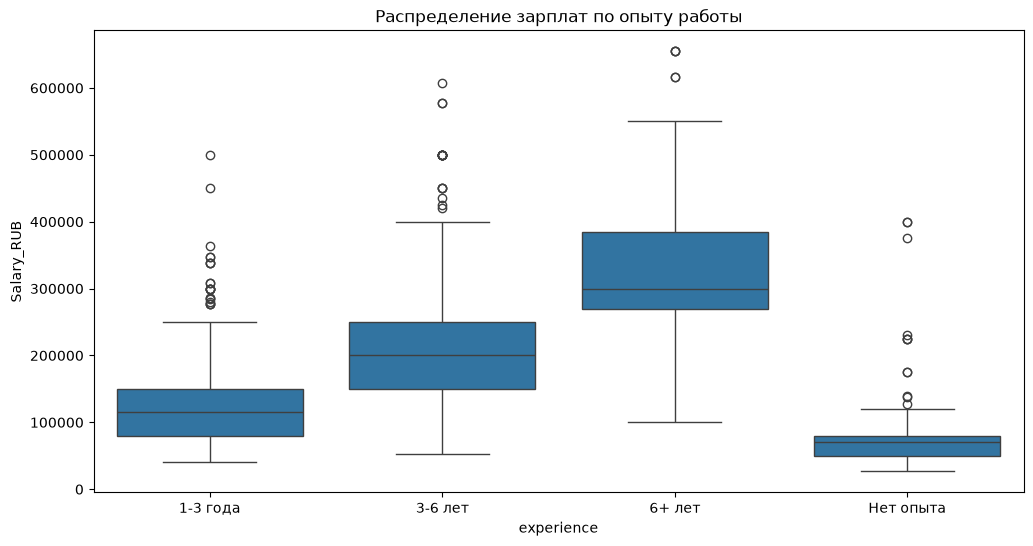

In [868]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='experience', y='Salary_RUB', data=train_df)
plt.title('Распределение зарплат по опыту работы')
plt.show()

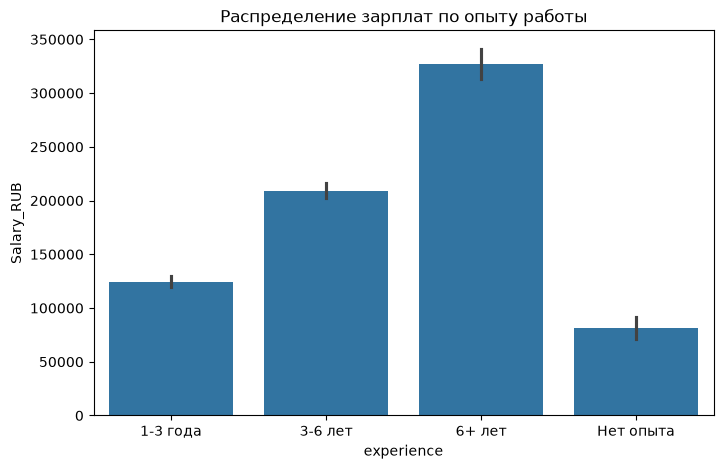

In [869]:
plt.figure(figsize=(8, 5))
sns.barplot(x='experience', y='Salary_RUB', data=train_df)
plt.title('Распределение зарплат по опыту работы')
plt.show()

In [870]:
exp_mapping = {
    "Нет опыта": 0,
    "1-3 года": 1,
    "3-6 лет": 2,
    "6+ лет": 3
}

train_df['Exp_Label'] = train_df['experience'].map(exp_mapping)

In [871]:
train_df.groupby(['work_format', 'common_employment'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
work_format common_employment                                                 
Гибрид      Полная занятость       326  165000.0  183944.555215   91607.851250
            Стажировка/Проект        1   53400.0   53400.000000            NaN
            Частичная занятость      2   90000.0   90000.000000   14142.135624
Не указано  Полная занятость        80  135000.0  155191.875000   99076.954634
Офис        Полная занятость       582  120000.0  142279.070962   85138.024691
            Частичная занятость      6   72500.0   96566.666667   41592.387124
Удалённо    Полная занятость       545  200000.0  231686.049541  121426.613566
            Стажировка/Проект       16  275000.0  254156.250000  114698.404341
            Частичная занятость     42   92500.0   89638.095238   28001.332306

In [872]:
train_df.groupby(['work_format'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
work_format,,,,
Гибрид,329,165000.0,182976.671733,91764.284403
Не указано,80,135000.0,155191.875000,99076.954634
Офис,588,120000.0,141812.617857,84913.305903
Удалённо,603,200000.0,222388.386401,122636.188716


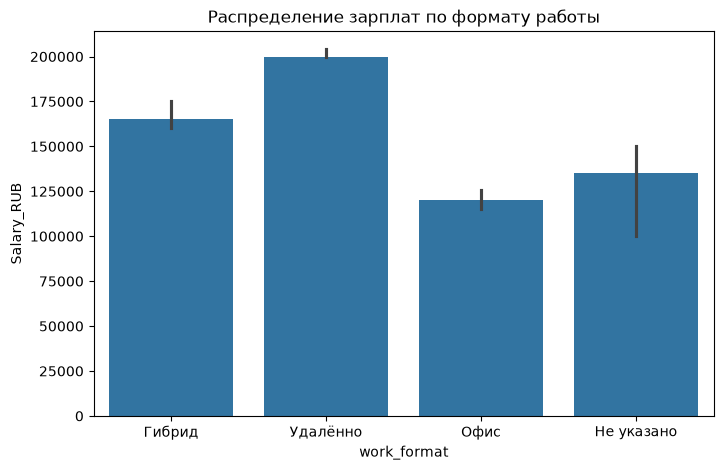

In [873]:
plt.figure(figsize=(8, 5))
sns.barplot(x='work_format', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по формату работы')
plt.show()

In [874]:
format_mapping = {
    "Не указано": 0,
    "Офис": 0,
    "Гибрид": 1,
    "Удалённо": 2
}

train_df['Format_Label'] = train_df['work_format'].map(format_mapping)

In [875]:
train_df.groupby(['common_employment'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
common_employment,,,,
Полная занятость,1533,152000.0,183598.559230,108556.039497
Стажировка/Проект,17,250000.0,242347.058824,121261.123808
Частичная занятость,50,85000.0,90484.000000,29014.144053


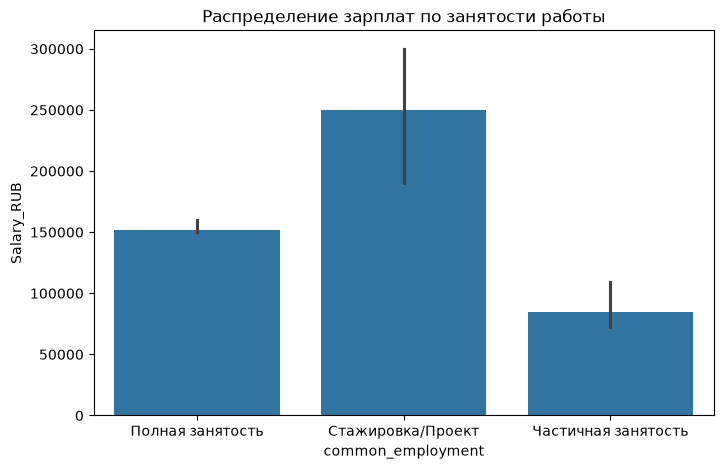

In [876]:
plt.figure(figsize=(8, 5))
sns.barplot(x='common_employment', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по занятости работы')
plt.show()

In [877]:
train_df['Is_Full_Time'] = (train_df['common_employment'] == 'Полная занятость').astype(int)
train_df['Is_Part_Time'] = (train_df['common_employment'] == 'Частичная занятость').astype(int)

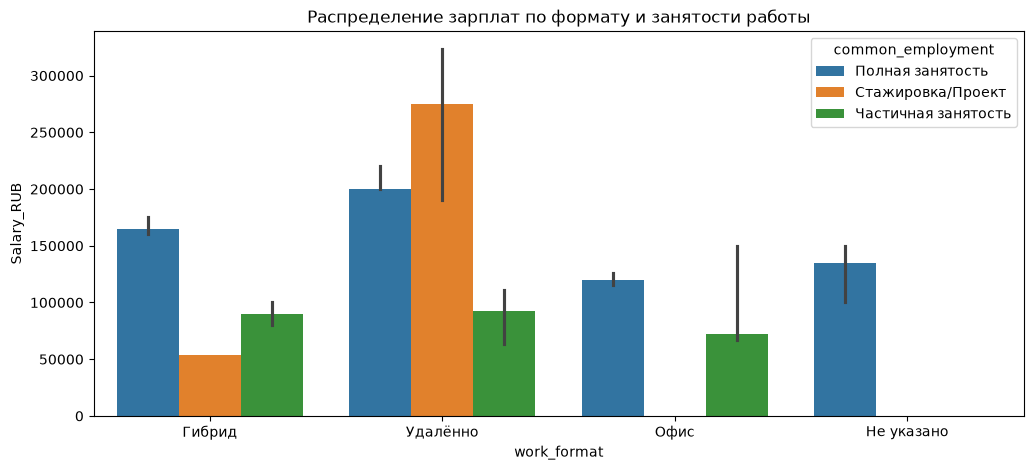

In [878]:
plt.figure(figsize=(12, 5))
sns.barplot(x='work_format', y='Salary_RUB', data=train_df, hue='common_employment', estimator=np.median)
plt.title('Распределение зарплат по формату и занятости работы')
plt.show()

In [879]:
train_df['Remote_Intern'] = ((train_df['work_format'] == 'Удалённо') & (train_df['common_employment'] == 'Стажировка/Проект')).astype(int)

In [880]:
train_df.groupby(['Remote_Intern'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
Remote_Intern,,,,
0,1584,150000.0,180577.140972,108195.380373
1,16,275000.0,254156.250000,114698.404341


In [881]:
train_df.groupby(['work_schedule'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
work_schedule,,,,
Другие,10,69300.0,89295.000000,53962.829028
Классический (5/2),1500,150000.0,184233.027533,109194.862268
Не указано,26,182500.0,176530.769231,93284.295653
Свободный,64,112500.0,129193.750000,82139.231148


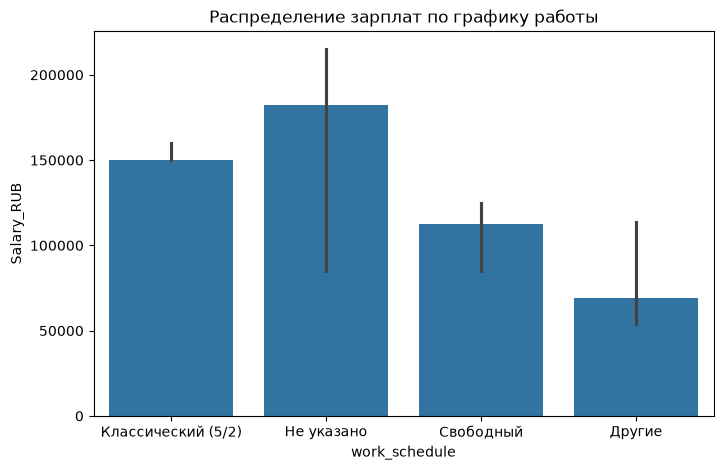

In [882]:
plt.figure(figsize=(8, 5))
sns.barplot(x='work_schedule', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по графику работы')
plt.show()

In [883]:
train_df.groupby(['work_schedule', 'experience'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
work_schedule      experience                                               
Другие             1-3 года        6   69300.0   71016.666667   18579.711157
                   3-6 лет         2  183925.0  183925.000000   36875.618639
                   Нет опыта       2   49500.0   49500.000000    6363.961031
Классический (5/2) 1-3 года      597  115000.0  125794.172529   60145.078305
                   3-6 лет       589  200000.0  212121.389304   92904.370080
                   6+ лет        208  300000.0  328136.644231  106662.517464
                   Нет опыта     106   70000.0   76023.584906   47985.483027
Не указано         1-3 года       15   85000.0  112133.333333   52800.658365
                   3-6 лет         5  246400.0  271560.000000   50439.944488
                   6+ лет          4  300000.0  300000.000000       0.000000
                   Нет опыта       2  175000.0  175000.000000       0.000000
Свободный          1-3 года       13  120000.0  106923.076923   26183.523886
                   3-6 лет        33  135000.0  148378.787879   76292.818951
                   6+ лет          1  155000.0  155000.000000            NaN
                   Нет опыта      17   75000.0  107464.705882  112716.275118

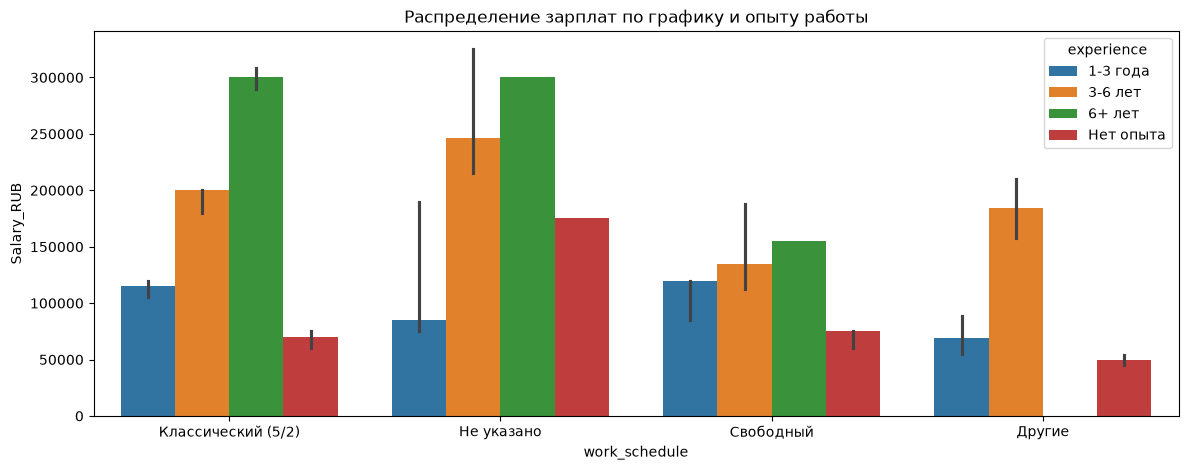

In [884]:
plt.figure(figsize=(14, 5))
sns.barplot(x='work_schedule', y='Salary_RUB', data=train_df, estimator=np.median, hue='experience')
plt.title('Распределение зарплат по графику и опыту работы')
plt.show()

In [885]:
train_df['Is_Classic_Schedule'] = (train_df['work_schedule'] == 'Классический (5/2)').astype(int)

In [886]:
train_df['Is_Classic_Schedule'].corr(train_df['Exp_Label'])

np.float64(0.09157336689006067)

In [887]:
train_df.groupby(['work_schedule', 'work_hours'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean  \
work_schedule      work_hours                                          
Другие             12 часов               3   54000.0   53000.000000   
                   8 часов                5   69300.0   94220.000000   
                   Другие                 1  105000.0  105000.000000   
                   По договоренности      1  157850.0  157850.000000   
Классический (5/2) 12 часов               8  450000.0  450000.000000   
                   6 часов                4  182500.0  161250.000000   
                   8 часов             1401  152000.0  183314.983084   
                   Другие                53  127500.0  159208.490566   
                   Не указано            10  346500.0  310920.000000   
                   По договоренности     24   90000.0  155541.666667   
Не указано         8 часов                1  104500.0  104500.000000   
                   Не указано            15  175000.0  192666.666667   
                   По договоренности     10  190000.0  159530.000000   
Свободный          8 часов               20  140000.0  145750.000000   
                   Другие                 5  125000.0  142000.000000   
                   По договоренности     39   85000.0  119061.538462   

                                                std  
work_schedule      work_hours                        
Другие             12 часов             7549.834435  
                   8 часов             65334.118193  
                   Другие                       NaN  
                   По договоренности            NaN  
Классический (5/2) 12 часов                0.000000  
                   6 часов             56623.758265  
                   8 часов            107510.242433  
                   Другие             106457.030757  
                   Не указано          97654.354173  
                   По договоренности   98898.297197  
Не указано         8 часов                      NaN  
                   Не указано         106349.603174  
                   По договоренности   72434.998447  
Свободный          8 часов             85058.416459  
                   Другие              33279.122585  
                   По договоренности   84736.745945

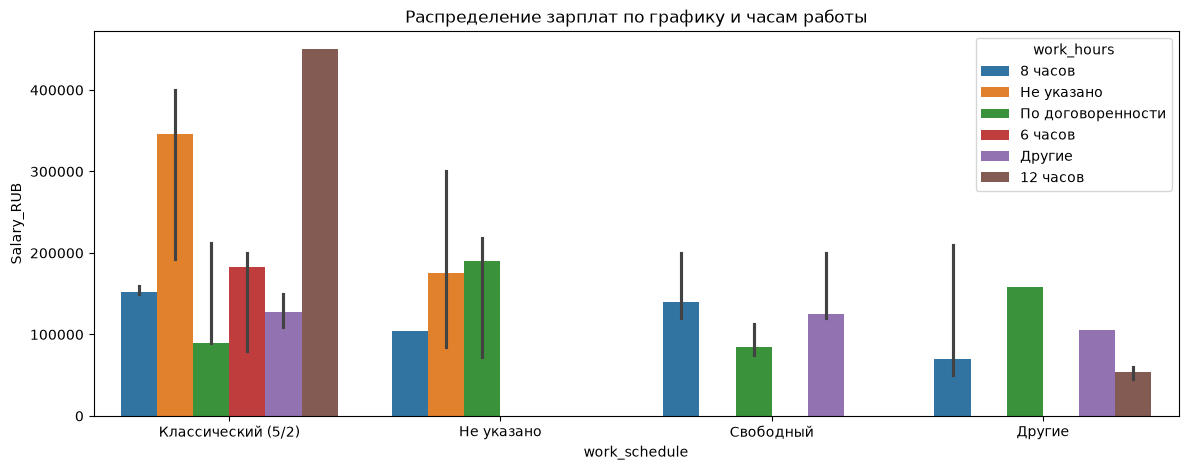

In [888]:
plt.figure(figsize=(14, 5))
sns.barplot(x='work_schedule', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_hours')
plt.title('Распределение зарплат по графику и часам работы')
plt.show()

In [889]:
train_df['Classic_Schedule_with_Other_Hours'] = ((train_df['work_schedule'] == 'Классический (5/2)') & (train_df['work_hours'] == 'Другие')).astype(int)

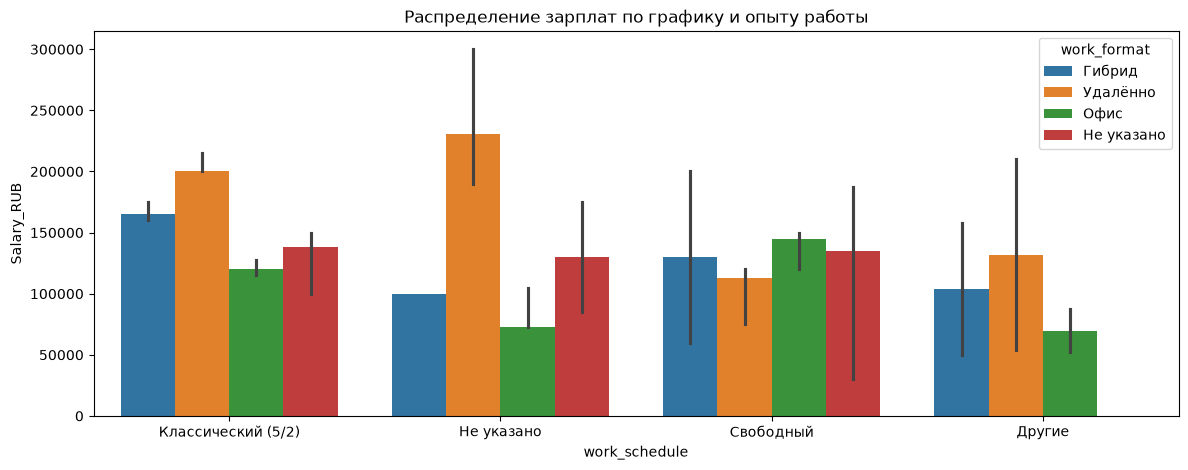

In [890]:
plt.figure(figsize=(14, 5))
sns.barplot(x='work_schedule', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_format')
plt.title('Распределение зарплат по графику и опыту работы')
plt.show()

In [891]:
train_df.groupby(['work_schedule', 'work_format'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
work_schedule      work_format                                               
Другие             Гибрид           2  103925.0  103925.000000   76261.466351
                   Офис             6   69300.0   70183.333333   19783.974997
                   Удалённо         2  132000.0  132000.000000  110308.657865
Классический (5/2) Гибрид         316  165000.0  185558.465190   91999.318803
                   Не указано      71  138000.0  160251.408451  102107.919090
                   Офис           570  120000.0  143176.875965   85594.432816
                   Удалённо       543  200000.0  229695.022099  122882.297664
Не указано         Гибрид           1  100000.0  100000.000000            NaN
                   Не указано       4  130000.0  130000.000000   51961.524227
                   Офис             5   72500.0   81400.000000   14001.785600
                   Удалённо        16  230700.0  222675.000000   87494.544592
Свободный          Гибрид          10  130000.0  125500.000000   62824.712052
                   Не указано       5  135000.0  103500.000000   70436.141291
                   Офис             7  145000.0  135271.428571   41968.429177
                   Удалённо        42  112500.0  132119.047619   93059.239559

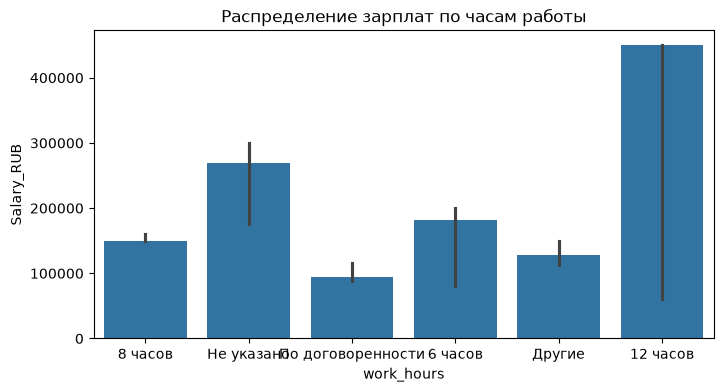

In [892]:
plt.figure(figsize=(8, 4))
sns.barplot(x='work_hours', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по часам работы')
plt.show()

In [893]:
train_df.groupby(['work_hours'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
work_hours,,,,
12 часов,11,450000.0,341727.272727,185469.183914
6 часов,4,182500.0,161250.000000,56623.758265
8 часов,1427,150000.0,182421.087106,107271.904047
Другие,59,127500.0,156831.355932,101526.028130
Не указано,25,269500.0,239968.000000,116917.669466
По договоренности,74,95000.0,136885.810811,88468.252382


In [894]:
train_df['Is_8_Hours'] = (train_df['work_hours'] == '8 часов').astype(int)
train_df['Is_Flexible_Hours'] = (train_df['work_hours'] == 'По договоренности').astype(int)

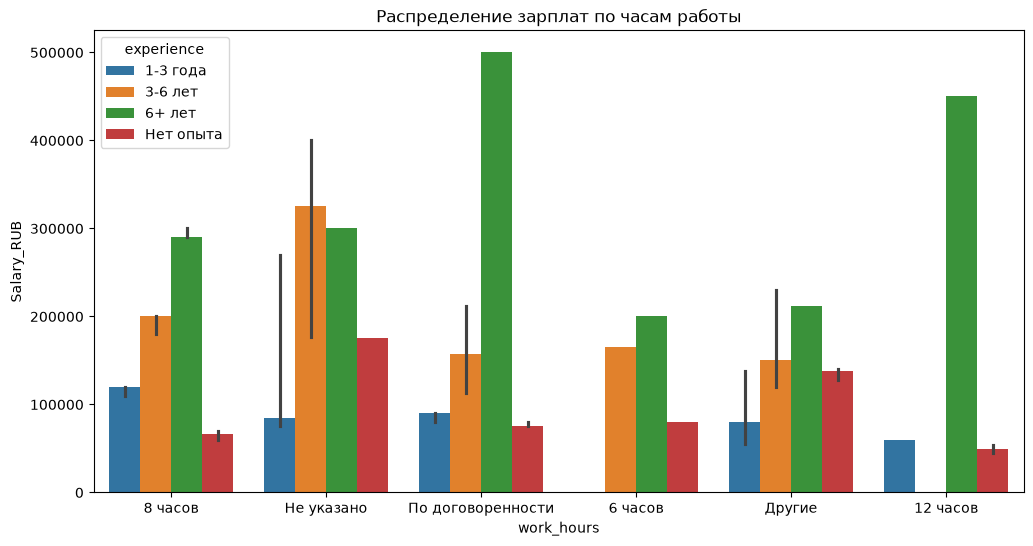

In [895]:
plt.figure(figsize=(12, 6))
sns.barplot(x='work_hours', y='Salary_RUB', data=train_df, estimator=np.median, hue='experience')
plt.title('Распределение зарплат по часам работы')
plt.show()

In [896]:
train_df.groupby(['work_hours', 'experience'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
work_hours        experience                                               
12 часов          1-3 года        1   60000.0   60000.000000            NaN
                  6+ лет          8  450000.0  450000.000000       0.000000
                  Нет опыта       2   49500.0   49500.000000    6363.961031
6 часов           3-6 лет         1  165000.0  165000.000000            NaN
                  6+ лет          2  200000.0  200000.000000       0.000000
                  Нет опыта       1   80000.0   80000.000000            NaN
8 часов           1-3 года      565  120000.0  126238.444248   58548.889877
                  3-6 лет       557  200000.0  210702.869479   91226.095906
                  6+ лет        197  290000.0  323328.284264  105601.099764
                  Нет опыта     108   66500.0   73453.703704   47399.797756
Другие            1-3 года       28   80000.0  107928.571429   62091.287974
                  3-6 лет        27  150000.0  207918.518519  116321.848060
                  6+ лет          1  211750.0  211750.000000            NaN
                  Нет опыта       3  138000.0  135166.666667    6714.412359
Не указано        1-3 года       10   85000.0  157550.000000  111360.637869
                  3-6 лет         9  325000.0  319300.000000   92895.546180
                  6+ лет          4  300000.0  300000.000000       0.000000
                  Нет опыта       2  175000.0  175000.000000       0.000000
По договоренности 1-3 года       27   90000.0   96851.851852   36818.111872
                  3-6 лет        35  157850.0  158504.285714   70812.587544
                  6+ лет          1  500000.0  500000.000000            NaN
                  Нет опыта      11   75000.0  133354.545455  131904.824503

In [897]:
train_df['High_Exp_with_8_Hours'] = ((train_df['work_hours'] == '8 часов') & (train_df['experience'] == '6+ лет')).astype(int)
train_df['Medium_Exp_with_8_Hours'] = ((train_df['work_hours'] == '8 часов') & (train_df['experience'] == '3-6 лет')).astype(int)
train_df['Low_Exp_with_8_Hours'] = ((train_df['work_hours'] == '8 часов') & (train_df['experience'] == '1-3 года')).astype(int)
train_df['Zero_Exp_with_8_Hours'] = ((train_df['work_hours'] == '8 часов') & (train_df['experience'] == 'Нет опыта')).astype(int)

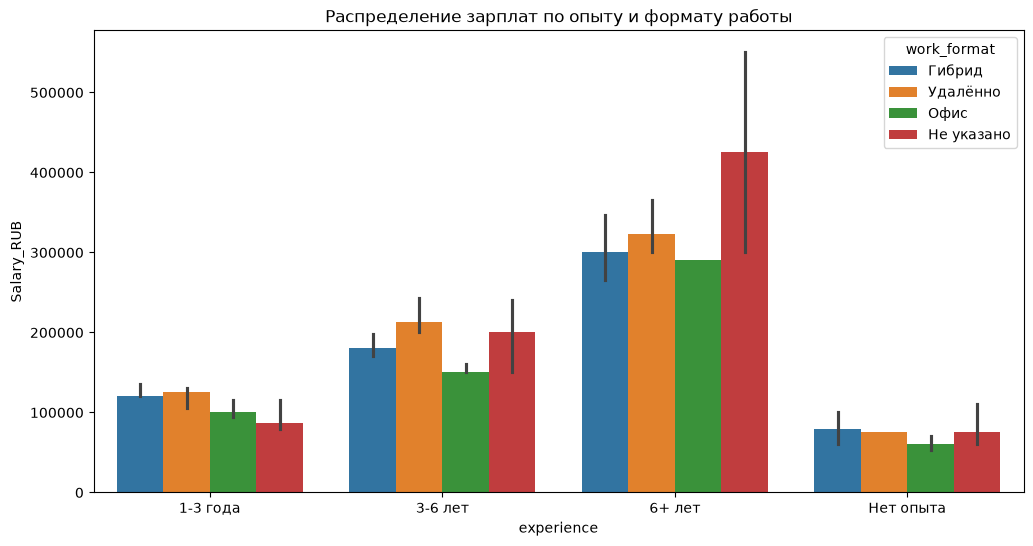

In [898]:
plt.figure(figsize=(12, 6))
sns.barplot(x='experience', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_format')
plt.title('Распределение зарплат по опыту и формату работы')
plt.show()

In [899]:
train_df.groupby(['experience', 'work_format'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
experience work_format                                               
1-3 года   Гибрид         139  120000.0  135449.640288   63297.557448
           Не указано      31   86750.0  119866.129032   86411.483021
           Офис           292  100000.0  113684.917808   47397.012563
           Удалённо       169  125000.0  135253.698225   65817.906646
3-6 лет    Гибрид         136  180000.0  199384.742647   75179.561051
           Не указано      35  200000.0  194214.285714   76922.926066
           Офис           156  150000.0  174363.290385   76418.157343
           Удалённо       302  213375.0  233268.708609  102561.659386
6+ лет     Гибрид          44  300000.0  305443.181818   87097.861020
           Не указано       2  425000.0  425000.000000  176776.695297
           Офис            58  290000.0  292875.000000   79042.366638
           Удалённо       109  323400.0  351662.128440  117879.593577
Нет опыта  Гибрид          10   79500.0   81600.000000   27048.105294
           Не указано      12   75000.0   87666.666667   49315.465642
           Офис            82   60000.0   73200.000000   51103.161217
           Удалённо        23   75000.0  107130.434783   98437.938154

In [900]:
train_df['Remote_Senior'] = ((train_df['work_format'] == 'Удалённо') & (train_df['experience'] == '6+ лет')).astype(int)
train_df['Remote_Middle'] = ((train_df['work_format'] == 'Удалённо') & (train_df['experience'] == '3-6 лет')).astype(int)
train_df['Office_Junior'] = ((train_df['work_format'] == 'Офис') & (train_df['experience'] == '1-3 года')).astype(int)

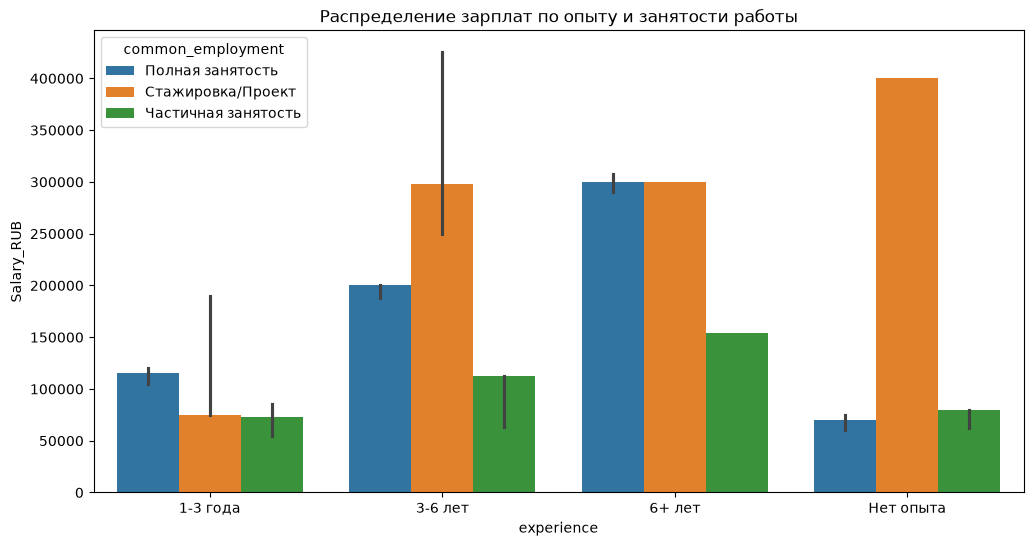

In [901]:
plt.figure(figsize=(12, 6))
sns.barplot(x='experience', y='Salary_RUB', data=train_df, estimator=np.median, hue='common_employment')
plt.title('Распределение зарплат по опыту и занятости работы')
plt.show()

In [902]:
train_df.groupby(['experience', 'common_employment'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
experience common_employment                                                 
1-3 года   Полная занятость       603  115500.0  126204.512438   59703.310426
           Стажировка/Проект        7   75000.0  121200.000000   64808.024195
           Частичная занятость     21   72500.0   78452.380952   24564.661997
3-6 лет    Полная занятость       600  200000.0  212982.247167   91606.979709
           Стажировка/Проект        4  298250.0  317875.000000   84674.253269
           Частичная занятость     25  112500.0  100032.000000   27981.045966
6+ лет     Полная занятость       208  300000.0  328141.451923  106654.652781
           Стажировка/Проект        4  300000.0  300000.000000       0.000000
           Частичная занятость      1  154000.0  154000.000000            NaN
Нет опыта  Полная занятость       122   70000.0   76331.967213   47476.336457
           Стажировка/Проект        2  400000.0  400000.000000       0.000000
           Частичная занятость      3   80000.0   73966.666667   10450.039872

In [903]:
train_df['Senior_Fulltime'] = ((train_df['experience'] == '6+ лет') & (train_df['common_employment'] == 'Полная занятость')).astype(int)
train_df['Junior_Fulltime'] = ((train_df['experience'] == '1-3 года') & (train_df['common_employment'] == 'Полная занятость')).astype(int)

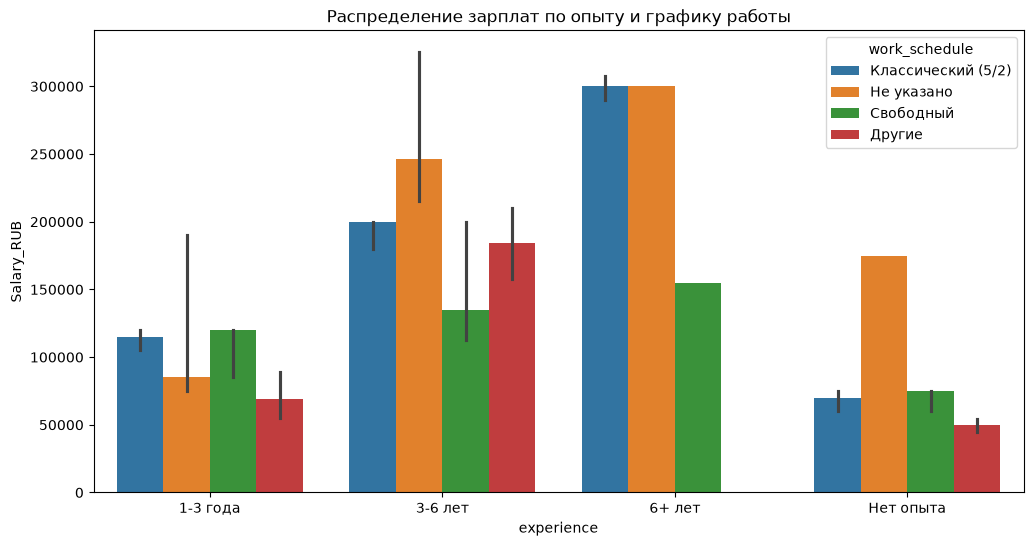

In [904]:
plt.figure(figsize=(12, 6))
sns.barplot(x='experience', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_schedule')
plt.title('Распределение зарплат по опыту и графику работы')
plt.show()

In [905]:
train_df.groupby(['experience', 'work_schedule'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
experience work_schedule                                                    
1-3 года   Другие                  6   69300.0   71016.666667   18579.711157
           Классический (5/2)    597  115000.0  125794.172529   60145.078305
           Не указано             15   85000.0  112133.333333   52800.658365
           Свободный              13  120000.0  106923.076923   26183.523886
3-6 лет    Другие                  2  183925.0  183925.000000   36875.618639
           Классический (5/2)    589  200000.0  212121.389304   92904.370080
           Не указано              5  246400.0  271560.000000   50439.944488
           Свободный              33  135000.0  148378.787879   76292.818951
6+ лет     Классический (5/2)    208  300000.0  328136.644231  106662.517464
           Не указано              4  300000.0  300000.000000       0.000000
           Свободный               1  155000.0  155000.000000            NaN
Нет опыта  Другие                  2   49500.0   49500.000000    6363.961031
           Классический (5/2)    106   70000.0   76023.584906   47985.483027
           Не указано              2  175000.0  175000.000000       0.000000
           Свободный              17   75000.0  107464.705882  112716.275118

In [906]:
train_df['Free_Middle'] = ((train_df['work_schedule'] == 'Свободный') & (train_df['experience'] == '3-6 лет')).astype(int)

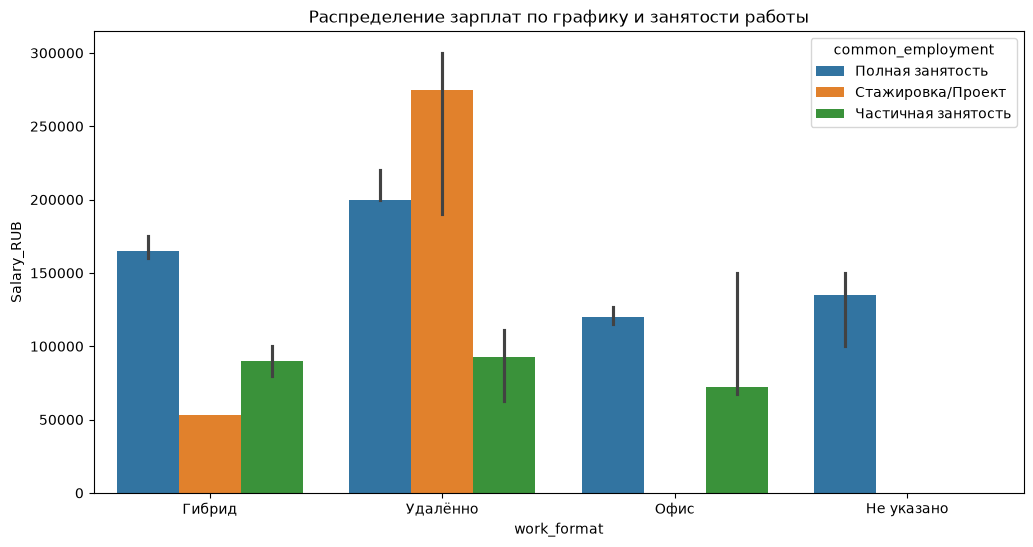

In [907]:
plt.figure(figsize=(12, 6))
sns.barplot(x='work_format', y='Salary_RUB', data=train_df, estimator=np.median, hue='common_employment')
plt.title('Распределение зарплат по графику и занятости работы')
plt.show()

In [908]:
train_df.groupby(['work_format', 'common_employment'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
work_format common_employment                                                 
Гибрид      Полная занятость       326  165000.0  183944.555215   91607.851250
            Стажировка/Проект        1   53400.0   53400.000000            NaN
            Частичная занятость      2   90000.0   90000.000000   14142.135624
Не указано  Полная занятость        80  135000.0  155191.875000   99076.954634
Офис        Полная занятость       582  120000.0  142279.070962   85138.024691
            Частичная занятость      6   72500.0   96566.666667   41592.387124
Удалённо    Полная занятость       545  200000.0  231686.049541  121426.613566
            Стажировка/Проект       16  275000.0  254156.250000  114698.404341
            Частичная занятость     42   92500.0   89638.095238   28001.332306

In [909]:
train_df['Remote_Fulltime'] = ((train_df['work_format'] == 'Удалённо') & (train_df['common_employment'] == 'Полная занятость')).astype(int)
train_df['Hybrid_Fulltime'] = ((train_df['work_format'] == 'Гибрид') & (train_df['common_employment'] == 'Полная занятость')).astype(int)
train_df['Office_Fulltime'] = ((train_df['work_format'] == 'Офис') & (train_df['common_employment'] == 'Полная занятость')).astype(int)

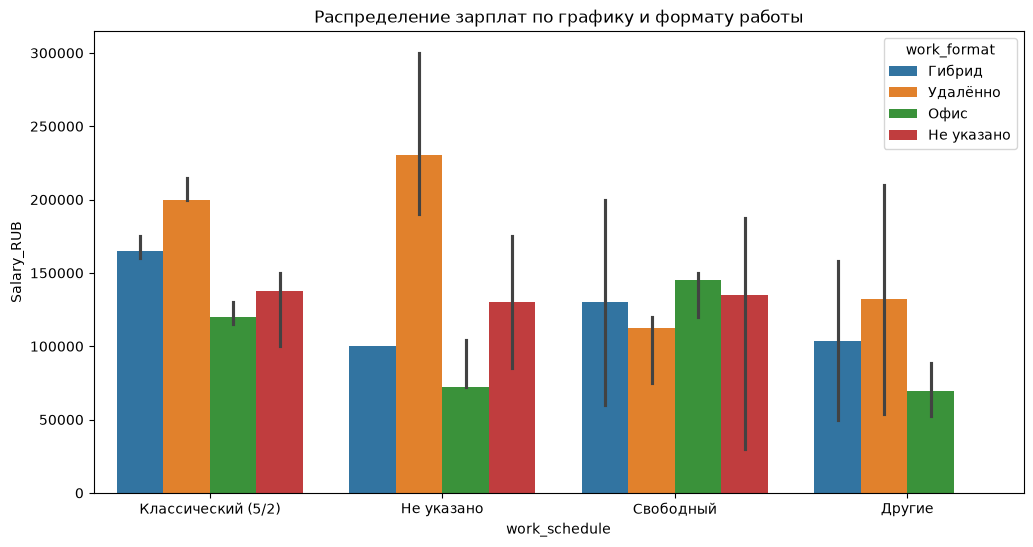

In [910]:
plt.figure(figsize=(12, 6))
sns.barplot(x='work_schedule', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_format')
plt.title('Распределение зарплат по графику и формату работы')
plt.show()

In [911]:
train_df.groupby(['work_schedule', 'work_format'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
work_schedule      work_format                                               
Другие             Гибрид           2  103925.0  103925.000000   76261.466351
                   Офис             6   69300.0   70183.333333   19783.974997
                   Удалённо         2  132000.0  132000.000000  110308.657865
Классический (5/2) Гибрид         316  165000.0  185558.465190   91999.318803
                   Не указано      71  138000.0  160251.408451  102107.919090
                   Офис           570  120000.0  143176.875965   85594.432816
                   Удалённо       543  200000.0  229695.022099  122882.297664
Не указано         Гибрид           1  100000.0  100000.000000            NaN
                   Не указано       4  130000.0  130000.000000   51961.524227
                   Офис             5   72500.0   81400.000000   14001.785600
                   Удалённо        16  230700.0  222675.000000   87494.544592
Свободный          Гибрид          10  130000.0  125500.000000   62824.712052
                   Не указано       5  135000.0  103500.000000   70436.141291
                   Офис             7  145000.0  135271.428571   41968.429177
                   Удалённо        42  112500.0  132119.047619   93059.239559

In [912]:
train_df['Classic_Remote'] = ((train_df['work_schedule'] == 'Классический (5/2)') & (train_df['work_format'] == 'Удалённо')).astype(int)
train_df['Classic_Office'] = ((train_df['work_schedule'] == 'Классический (5/2)') & (train_df['work_format'] == 'Офис')).astype(int)
train_df['Classic_Hybrid'] = ((train_df['work_schedule'] == 'Классический (5/2)') & (train_df['work_format'] == 'Гибрид')).astype(int)

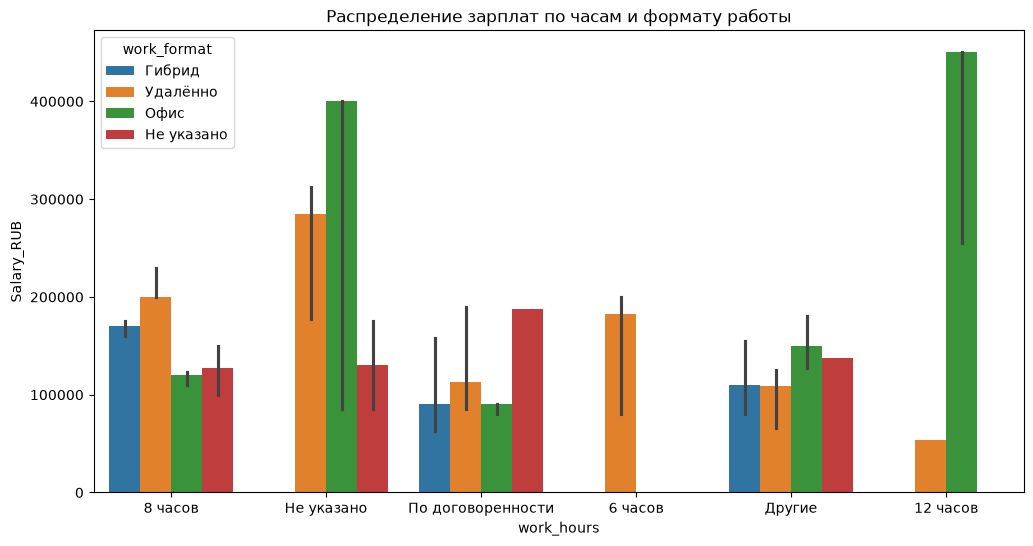

In [913]:
plt.figure(figsize=(12, 6))
sns.barplot(x='work_hours', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_format')
plt.title('Распределение зарплат по часам и формату работы')
plt.show()

In [914]:
train_df.groupby(['work_hours', 'work_format'])['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count    median           mean            std
work_hours        work_format                                               
12 часов          Офис            10  450000.0  370500.000000  167638.002851
                  Удалённо         1   54000.0   54000.000000            NaN
6 часов           Удалённо         4  182500.0  161250.000000   56623.758265
8 часов           Гибрид         317  170000.0  185872.160883   91938.346885
                  Не указано      74  127500.0  156349.324324  102262.498480
                  Офис           532  120000.0  135512.536278   74060.355452
                  Удалённо       504  200000.0  233593.049603  122254.766326
Другие            Гибрид           4  110000.0  113750.000000   39449.334595
                  Не указано       1  138000.0  138000.000000            NaN
                  Офис            26  150000.0  174471.153846   84303.390410
                  Удалённо        28  109200.0  147278.571429  121269.166052
Не указано        Не указано       4  130000.0  130000.000000   51961.524227
                  Офис             5  400000.0  337000.000000  140872.282582
                  Удалённо        16  284750.0  237137.500000   98325.214637
По договоренности Гибрид           8   90000.0  102856.250000   43249.867361
                  Не указано       1  187500.0  187500.000000            NaN
                  Офис            15   90000.0   91126.666667   25488.890204
                  Удалённо        50  112500.0  155046.000000   99941.890177

In [915]:
train_df['Hours_8_Remote'] = ((train_df['work_hours'] == '8 часов') & (train_df['work_format'] == 'Удалённо')).astype(int)
train_df['Hours_8_Hybrid'] = ((train_df['work_hours'] == '8 часов') & (train_df['work_format'] == 'Гибрид')).astype(int)
train_df['Hours_8_Office'] = ((train_df['work_hours'] == '8 часов') & (train_df['work_format'] == 'Офис')).astype(int)
train_df['Hours_12_Office'] = ((train_df['work_hours'] == '12 часов') & (train_df['work_format'] == 'Офис')).astype(int)

<h1>Анализ на мультиколлинеарность, слабые и дублирующиеся признаки</h1>

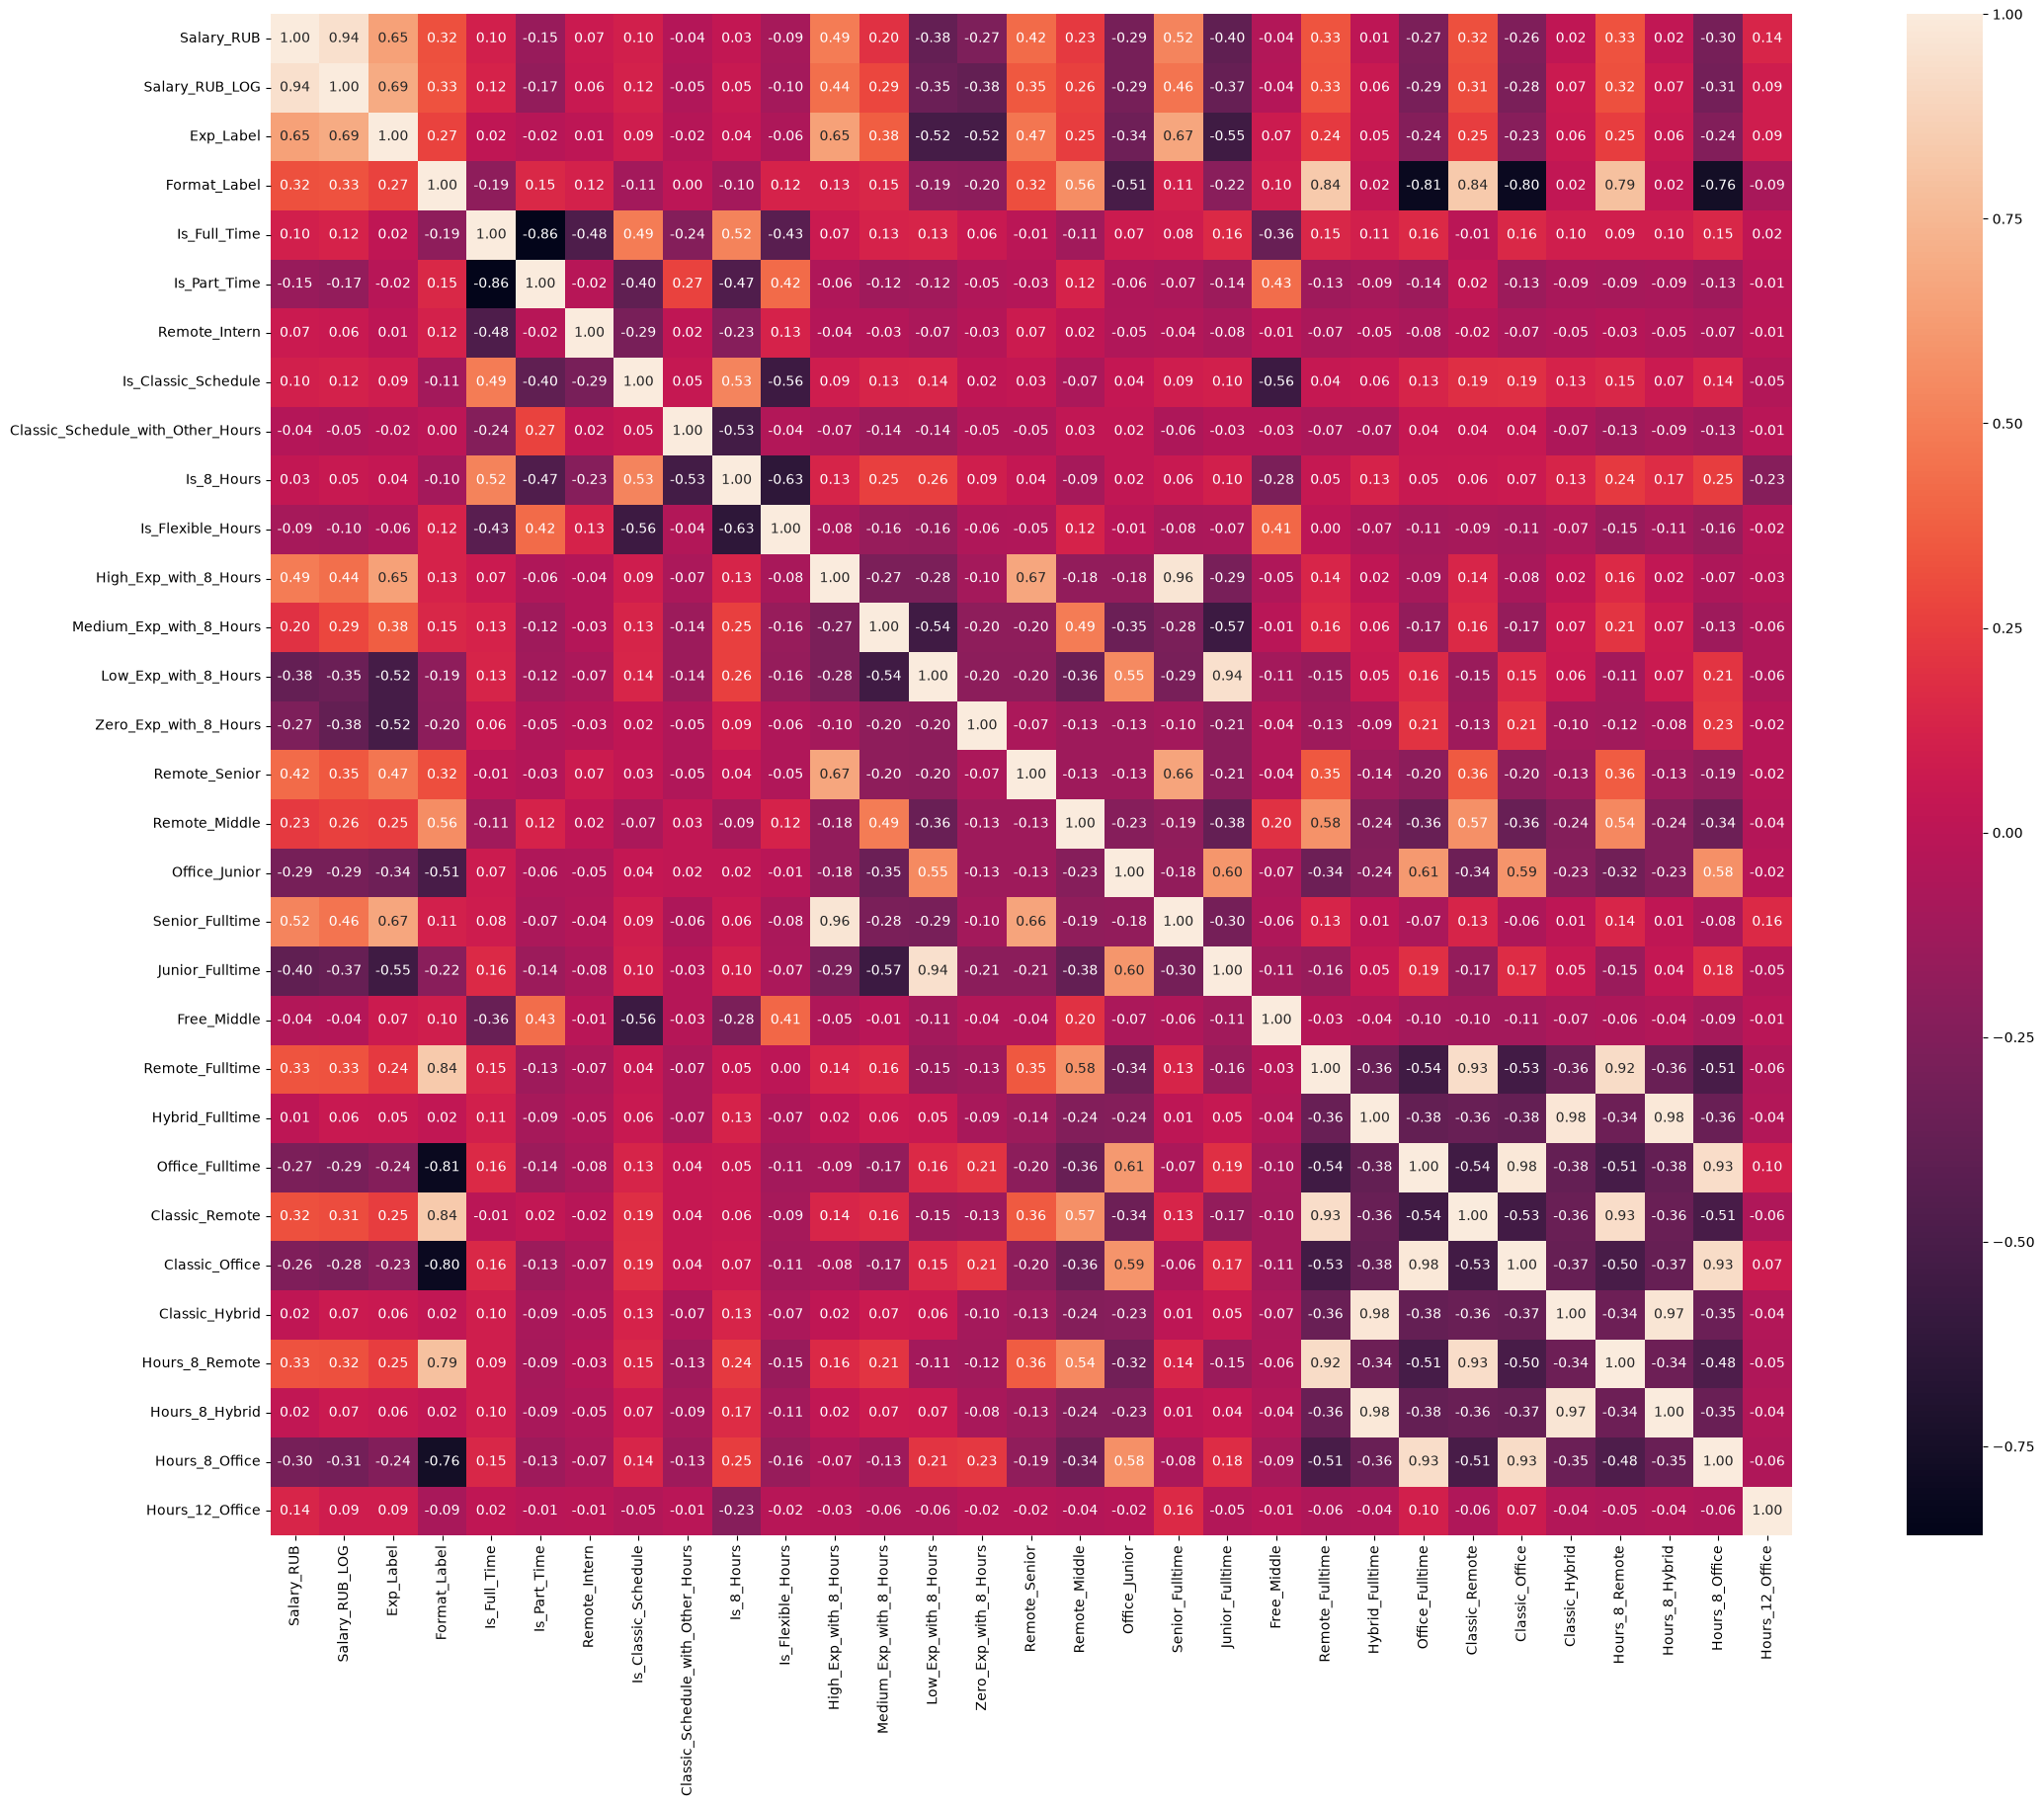

In [916]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(30, 20))
sns.heatmap(matrix, square=True, annot=True, fmt='.2f')
plt.show()

In [917]:
high_corr = train_df[numeric_cols].corr().stack()
high_corr = high_corr[(high_corr > 0.8) & (high_corr < 1)].sort_values(ascending=False)
print(high_corr)

Classic_Office         Office_Fulltime          0.983855
Office_Fulltime        Classic_Office           0.983855
Hours_8_Hybrid         Hybrid_Fulltime          0.978742
Hybrid_Fulltime        Hours_8_Hybrid           0.978742
                       Classic_Hybrid           0.976804
Classic_Hybrid         Hybrid_Fulltime          0.976804
Hours_8_Hybrid         Classic_Hybrid           0.966523
Classic_Hybrid         Hours_8_Hybrid           0.966523
Senior_Fulltime        High_Exp_with_8_Hours    0.963720
High_Exp_with_8_Hours  Senior_Fulltime          0.963720
Salary_RUB_LOG         Salary_RUB               0.942024
Salary_RUB             Salary_RUB_LOG           0.942024
Low_Exp_with_8_Hours   Junior_Fulltime          0.941947
Junior_Fulltime        Low_Exp_with_8_Hours     0.941947
Hours_8_Office         Office_Fulltime          0.933432
Office_Fulltime        Hours_8_Office           0.933432
Classic_Remote         Hours_8_Remote           0.931915
Hours_8_Remote         Classic_

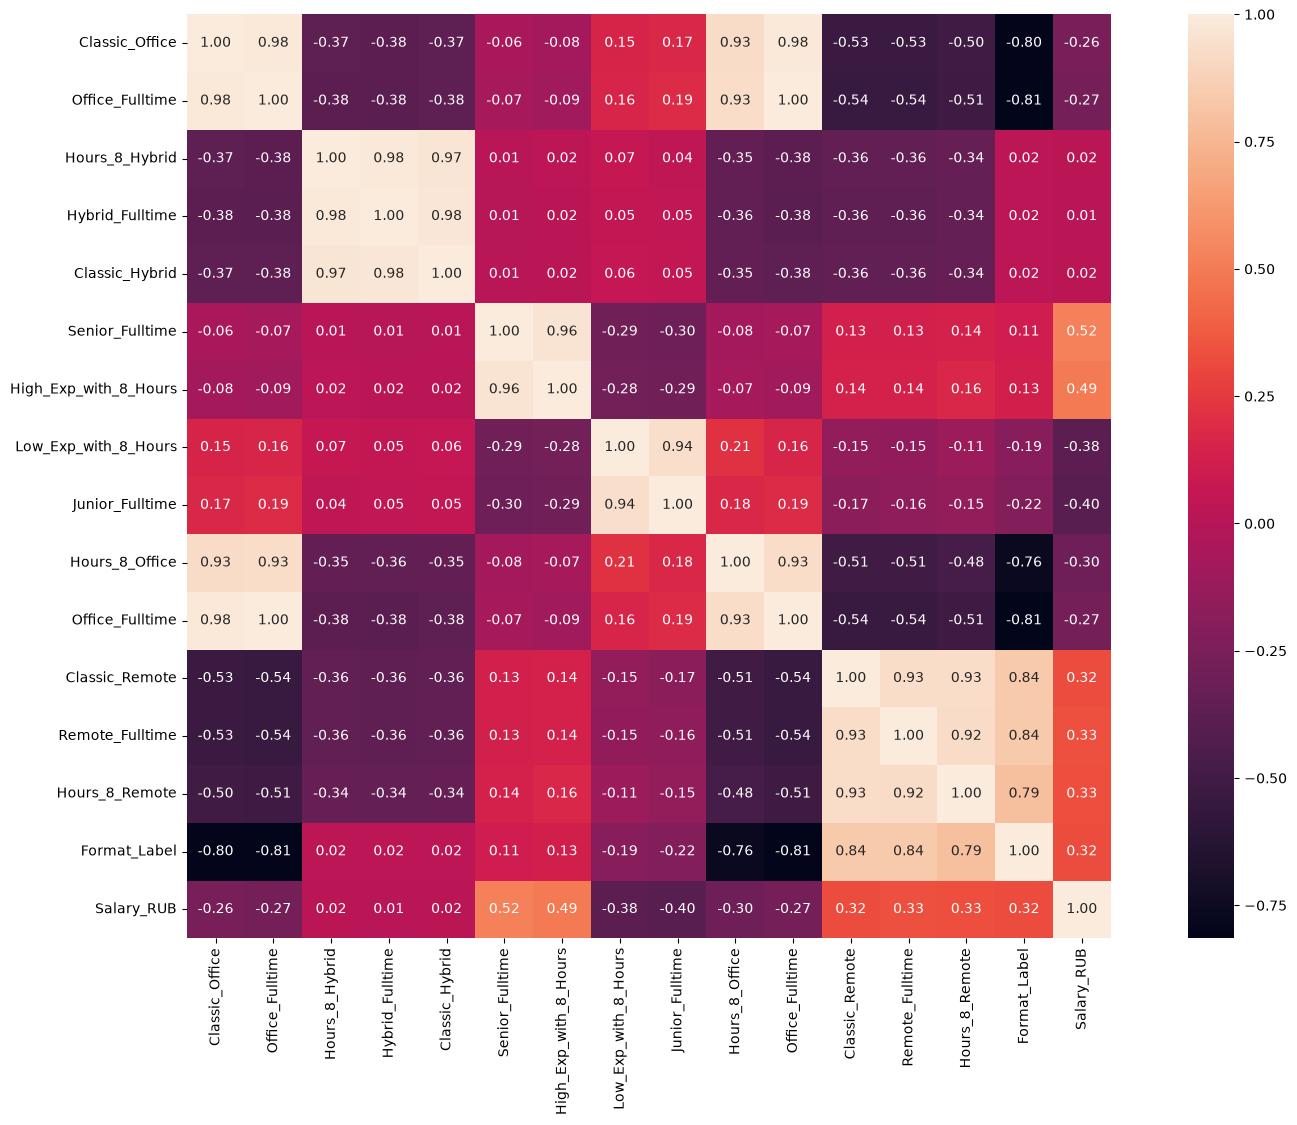

In [918]:
matrix = train_df[['Classic_Office', 'Office_Fulltime', 'Hours_8_Hybrid', 'Hybrid_Fulltime', 'Classic_Hybrid', 'Senior_Fulltime', 'High_Exp_with_8_Hours', 'Low_Exp_with_8_Hours', 'Junior_Fulltime', 'Hours_8_Office', 'Office_Fulltime', 'Classic_Remote', 'Remote_Fulltime', 'Hours_8_Remote', 'Format_Label', 'Salary_RUB']].corr()

plt.figure(figsize=(20, 12))
sns.heatmap(matrix, square=True, annot=True, fmt='.2f')
plt.show()

In [919]:
remove_corr_columns = ['Classic_Office', 'Hybrid_Fulltime', 'Classic_Hybrid', 'High_Exp_with_8_Hours', 'Junior_Fulltime', 'Hours_8_Office', 'Remote_Fulltime', 'Hours_8_Remote']
train_df.drop(remove_corr_columns, axis=1, inplace=True)

In [920]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

weak_features = [col for col in numeric_cols if abs(train_df[col].corr(train_df['Salary_RUB'])) < 0.1]
print(f"Слабые признаки ({len(weak_features)}): {weak_features}")

Слабые признаки (6): ['Remote_Intern', 'Classic_Schedule_with_Other_Hours', 'Is_8_Hours', 'Is_Flexible_Hours', 'Free_Middle', 'Hours_8_Hybrid']


In [921]:
train_df.drop(['Remote_Intern', 'Free_Middle'], axis=1, inplace=True)

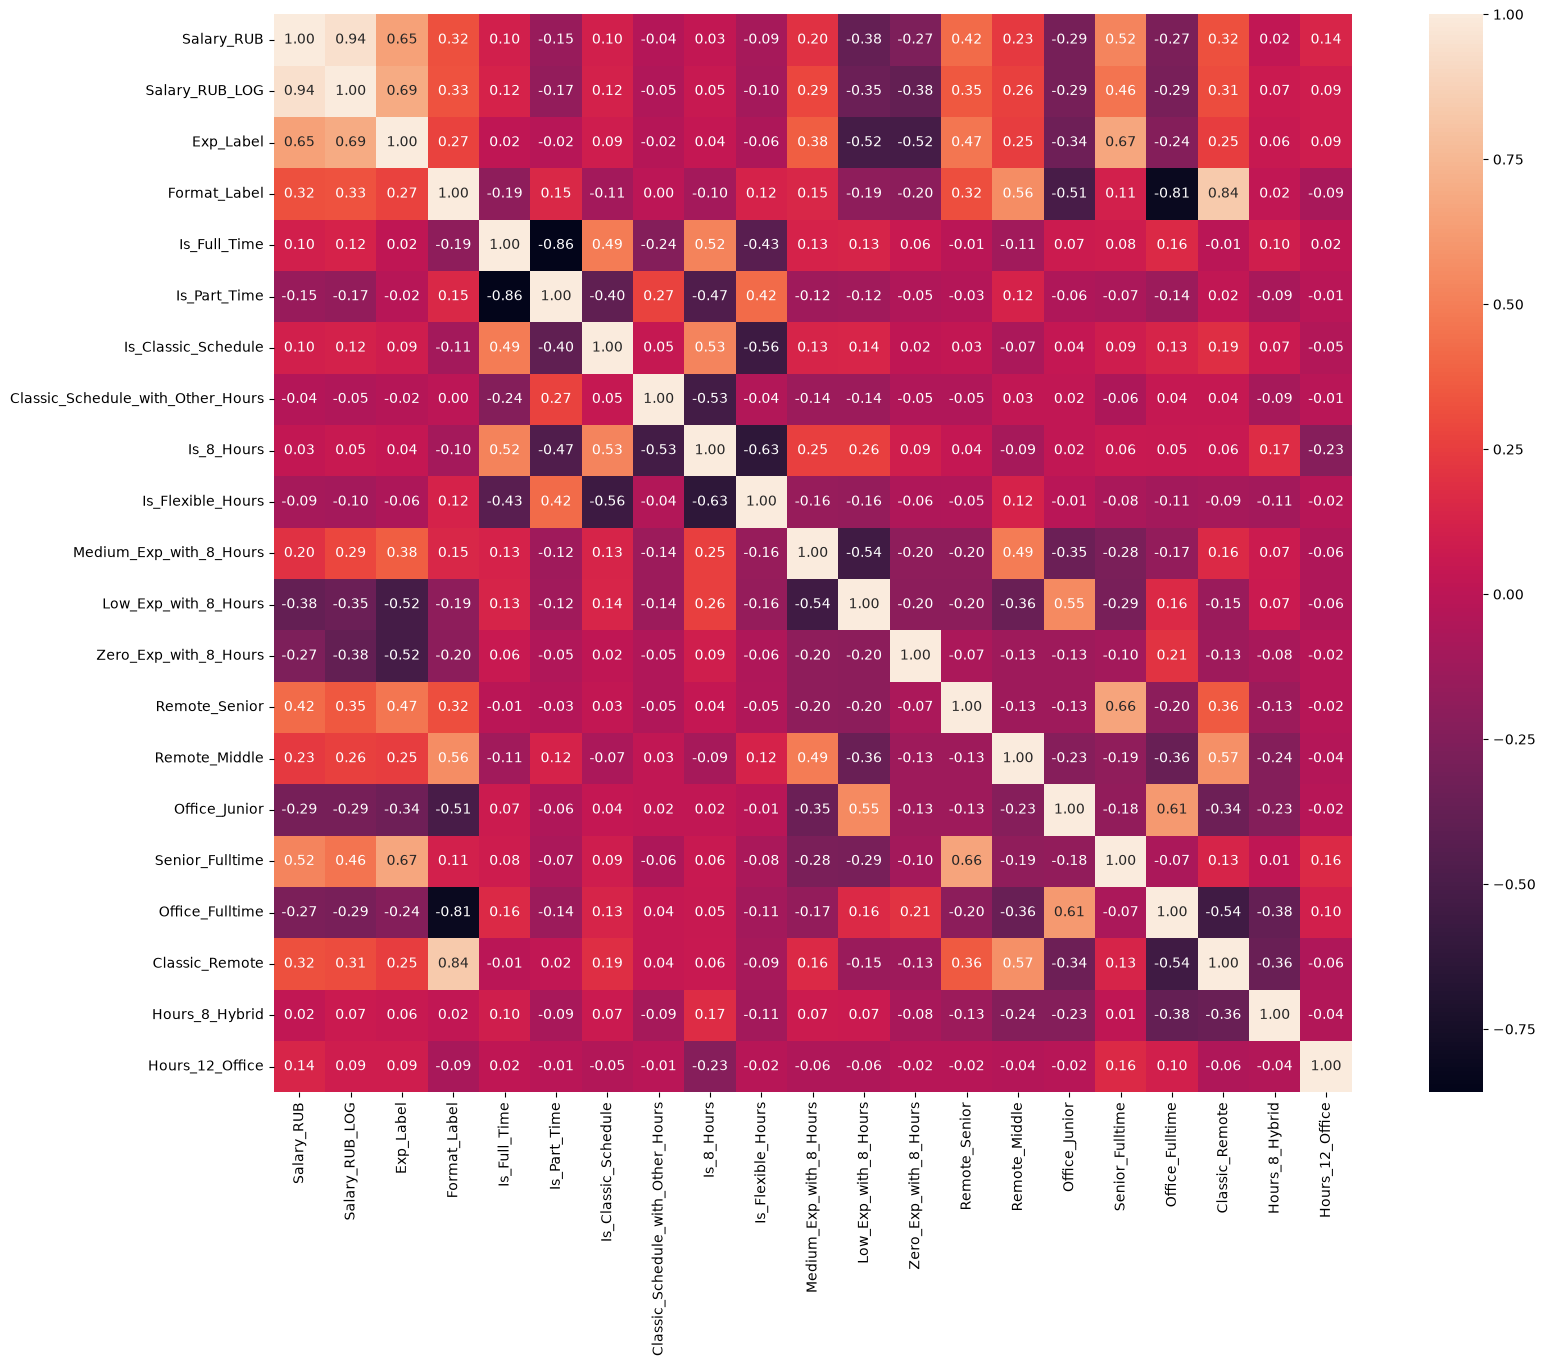

In [922]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(20, 14))
sns.heatmap(matrix, square=True, annot=True, fmt='.2f')
plt.show()

<h1>Применение подходящих свойств к валидационной выборке</h1>

In [923]:
val_df['Exp_Label'] = val_df['experience'].map(exp_mapping)
val_df['Format_Label'] = val_df['work_format'].map(format_mapping)

val_df['Is_Full_Time'] = (val_df['common_employment'] == 'Полная занятость').astype(int)
val_df['Is_Part_Time'] = (val_df['common_employment'] == 'Частичная занятость').astype(int)

val_df['Is_Classic_Schedule'] = (val_df['work_schedule'] == 'Классический (5/2)').astype(int)

val_df['Classic_Schedule_with_Other_Hours'] = ((val_df['work_schedule'] == 'Классический (5/2)') & (val_df['work_hours'] == 'Другие')).astype(int)

val_df['Is_Flexible_Hours'] = (val_df['work_hours'] == 'По договоренности').astype(int)
val_df['Is_8_Hours'] = (val_df['work_hours'] == '8 часов').astype(int)

val_df['Medium_Exp_with_8_Hours'] = ((val_df['work_hours'] == '8 часов') & (val_df['experience'] == '3-6 лет')).astype(int)
val_df['Low_Exp_with_8_Hours'] = ((val_df['work_hours'] == '8 часов') & (val_df['experience'] == '1-3 года')).astype(int)
val_df['Zero_Exp_with_8_Hours'] = ((val_df['work_hours'] == '8 часов') & (val_df['experience'] == 'Нет опыта')).astype(int)

val_df['Remote_Senior'] = ((val_df['work_format'] == 'Удалённо') & (val_df['experience'] == '6+ лет')).astype(int)
val_df['Remote_Middle'] = ((val_df['work_format'] == 'Удалённо') & (val_df['experience'] == '3-6 лет')).astype(int)
val_df['Office_Junior'] = ((val_df['work_format'] == 'Офис') & (val_df['experience'] == '1-3 года')).astype(int)

val_df['Senior_Fulltime'] = ((val_df['experience'] == '6+ лет') & (val_df['common_employment'] == 'Полная занятость')).astype(int)

val_df['Office_Fulltime'] = ((val_df['work_format'] == 'Офис') & (val_df['common_employment'] == 'Полная занятость')).astype(int)

val_df['Classic_Remote'] = ((val_df['work_schedule'] == 'Классический (5/2)') & (val_df['work_format'] == 'Удалённо')).astype(int)

val_df['Hours_8_Hybrid'] = ((val_df['work_hours'] == '8 часов') & (val_df['work_format'] == 'Гибрид')).astype(int)
val_df['Hours_12_Office'] = ((val_df['work_hours'] == '12 часов') & (val_df['work_format'] == 'Офис')).astype(int)

In [924]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 1496 to 1535
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   title                              400 non-null    object 
 1   experience                         400 non-null    object 
 2   work_format                        400 non-null    object 
 3   common_employment                  400 non-null    object 
 4   work_schedule                      400 non-null    object 
 5   work_hours                         400 non-null    object 
 6   name_company                       400 non-null    object 
 7   city                               400 non-null    object 
 8   address                            400 non-null    object 
 9   count_payments                     400 non-null    object 
 10  detailed_information               400 non-null    object 
 11  skills                             400 non-null    object 


<h1>Первый вызов с созданными фичами</h1>

In [925]:
models = [LinearRegression(), Ridge(), Lasso(), KNeighborsRegressor()]
models_names = ['LinearRegression', 'Ridge', 'Lasso', 'KNeighborsRegressor()']

numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

final_train_df = train_df[numeric_cols]
final_val_df = val_df[numeric_cols]

X_train = final_train_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_train = final_train_df['Salary_RUB_LOG']
X_val = final_val_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_val = final_val_df['Salary_RUB_LOG']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    y_pred_original = np.expm1(y_pred_log)
    y_val_original = np.expm1(y_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_original, y_pred_original):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_original, y_pred_original):.2f}")
    print()

Модель - LinearRegression
Метрики: 
Средняя абсолютная ошибка (MAE) = 57415.51
Коэффициент детерминации (RMSE) = 0.51

Модель - Ridge
Метрики: 
Средняя абсолютная ошибка (MAE) = 57365.48
Коэффициент детерминации (RMSE) = 0.51

Модель - Lasso
Метрики: 
Средняя абсолютная ошибка (MAE) = 87750.97
Коэффициент детерминации (RMSE) = -0.05

Модель - KNeighborsRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 58115.04
Коэффициент детерминации (RMSE) = 0.47



In [926]:
models = [DecisionTreeRegressor(), RandomForestRegressor(), GradientBoostingRegressor()]
models_names = ['DecisionTreeRegressor()', 'RandomForestRegressor()', 'GradientBoostingRegressor()']

y_train_orig = final_train_df['Salary_RUB']
y_val_orig = final_val_df['Salary_RUB']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train_orig)
    y_pred = model.predict(X_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_orig, y_pred):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_orig, y_pred):.2f}")
    print()

Модель - DecisionTreeRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 55761.34
Коэффициент детерминации (RMSE) = 0.55

Модель - RandomForestRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 55945.18
Коэффициент детерминации (RMSE) = 0.56

Модель - GradientBoostingRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 56893.83
Коэффициент детерминации (RMSE) = 0.54



<h1>Обработка столбца City</h1>

In [927]:
train_df['city'].value_counts()

city
Kazan           673
Moscow          304
SPB             117
Novosibirsk      55
Vladivostok      52
Ekaterinburg     52
Ufa              47
Krasnodar        39
Rostov           37
Volgograd        36
Yaroslavl        35
Samara           35
Krasnoyarsk      32
Saratov          24
Voronezh         23
Sochi            18
NN               14
Kaluga            7
Name: count, dtype: int64

In [928]:
train_df.groupby('city')['Salary_RUB'].agg(['count', 'mean', 'median', 'std']).sort_values(by='median', ascending=False)

,count,mean,median,std
city,,,,
Moscow,304,221238.888158,200000.0,105261.867199
Kazan,673,194424.031649,165000.0,120866.100234
SPB,117,177016.666667,165000.0,92149.350289
Ekaterinburg,52,166561.538462,150000.0,82957.400251
Novosibirsk,55,172286.363636,150000.0,102347.384330
Krasnodar,39,152842.307692,150000.0,78470.159044
Ufa,47,156808.510638,150000.0,80857.668373
Volgograd,36,146637.500000,145000.0,70971.095097
Voronezh,23,126086.956522,130000.0,39713.648952


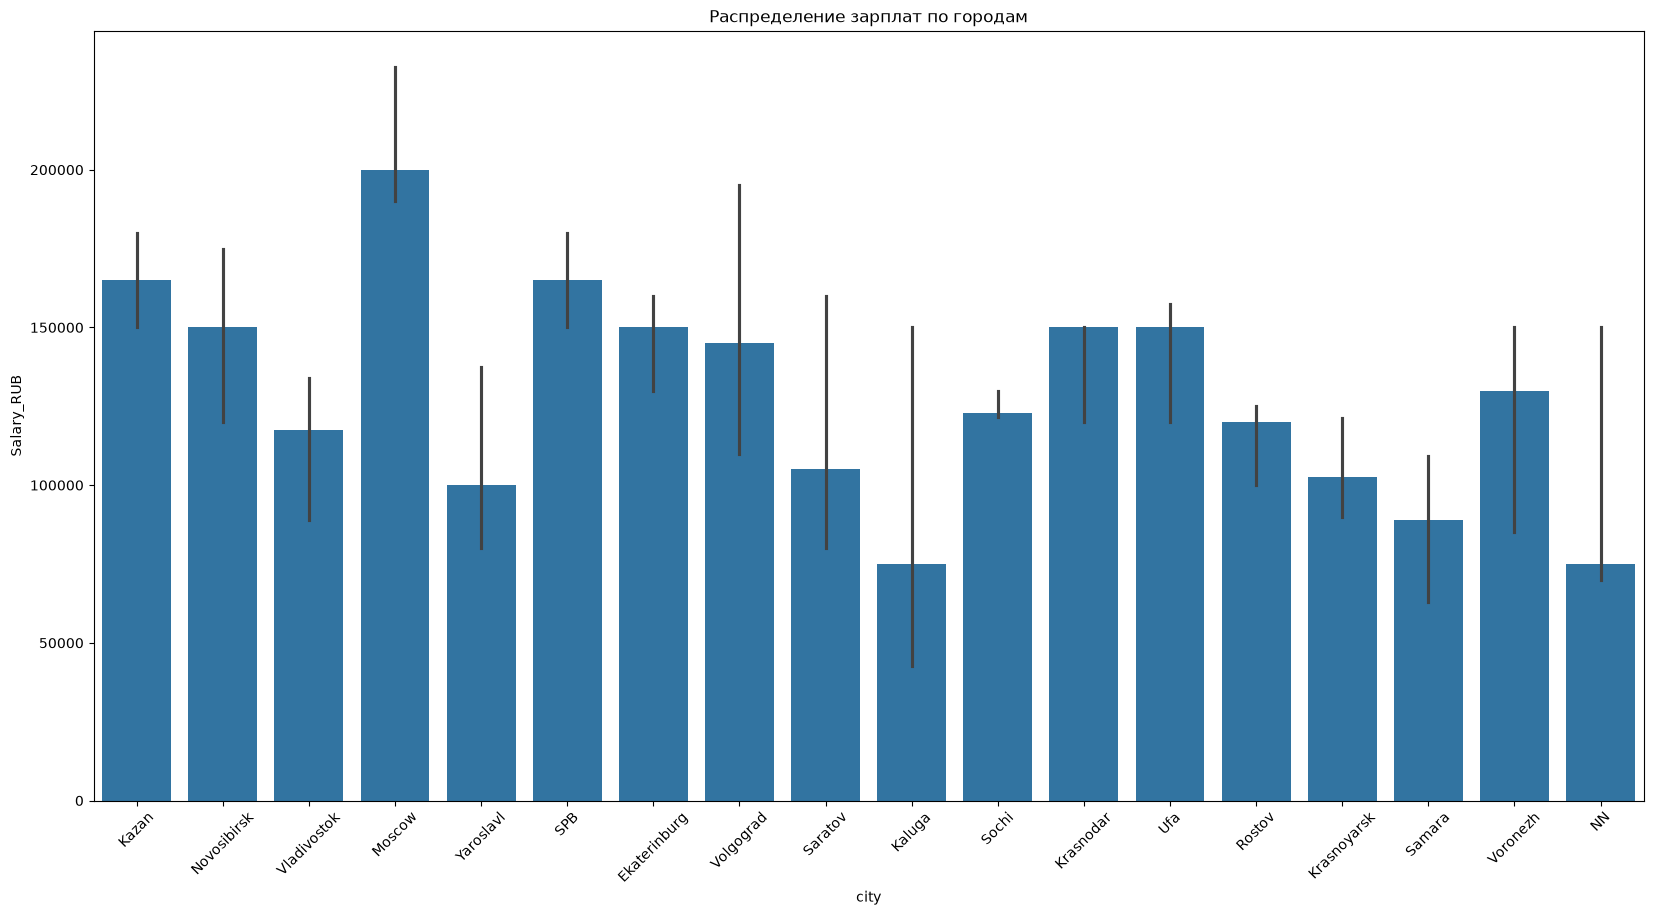

In [929]:
plt.figure(figsize=(20, 10))
sns.barplot(x='city', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по городам')
plt.xticks(rotation=45)
plt.show()

In [930]:
train_df['Is_Moscow'] = (train_df['city'] == 'Moscow').astype(int)

In [931]:
train_df['Is_Moscow'].corr(train_df['Salary_RUB'])

np.float64(0.1783233550543704)

In [932]:
train_df['Is_Kazan_SPB'] = (train_df['city'].isin(['Kazan', 'SPB'])).astype(int)

In [933]:
train_df['Is_Million_city'] = (train_df['city'].isin(['Ekaterinburg', 'Novosibirsk', 'Krasnodar', 'Ufa', 'Volgograd'])).astype(int)

In [934]:
train_df['Other_City'] = (~train_df['city'].isin(['Moscow', 'Kazan', 'SPB', 'Ekaterinburg', 'Novosibirsk', 'Krasnodar', 'Ufa', 'Volgograd'])).astype(int)

In [936]:
train_df.drop('address', axis=1, inplace=True)

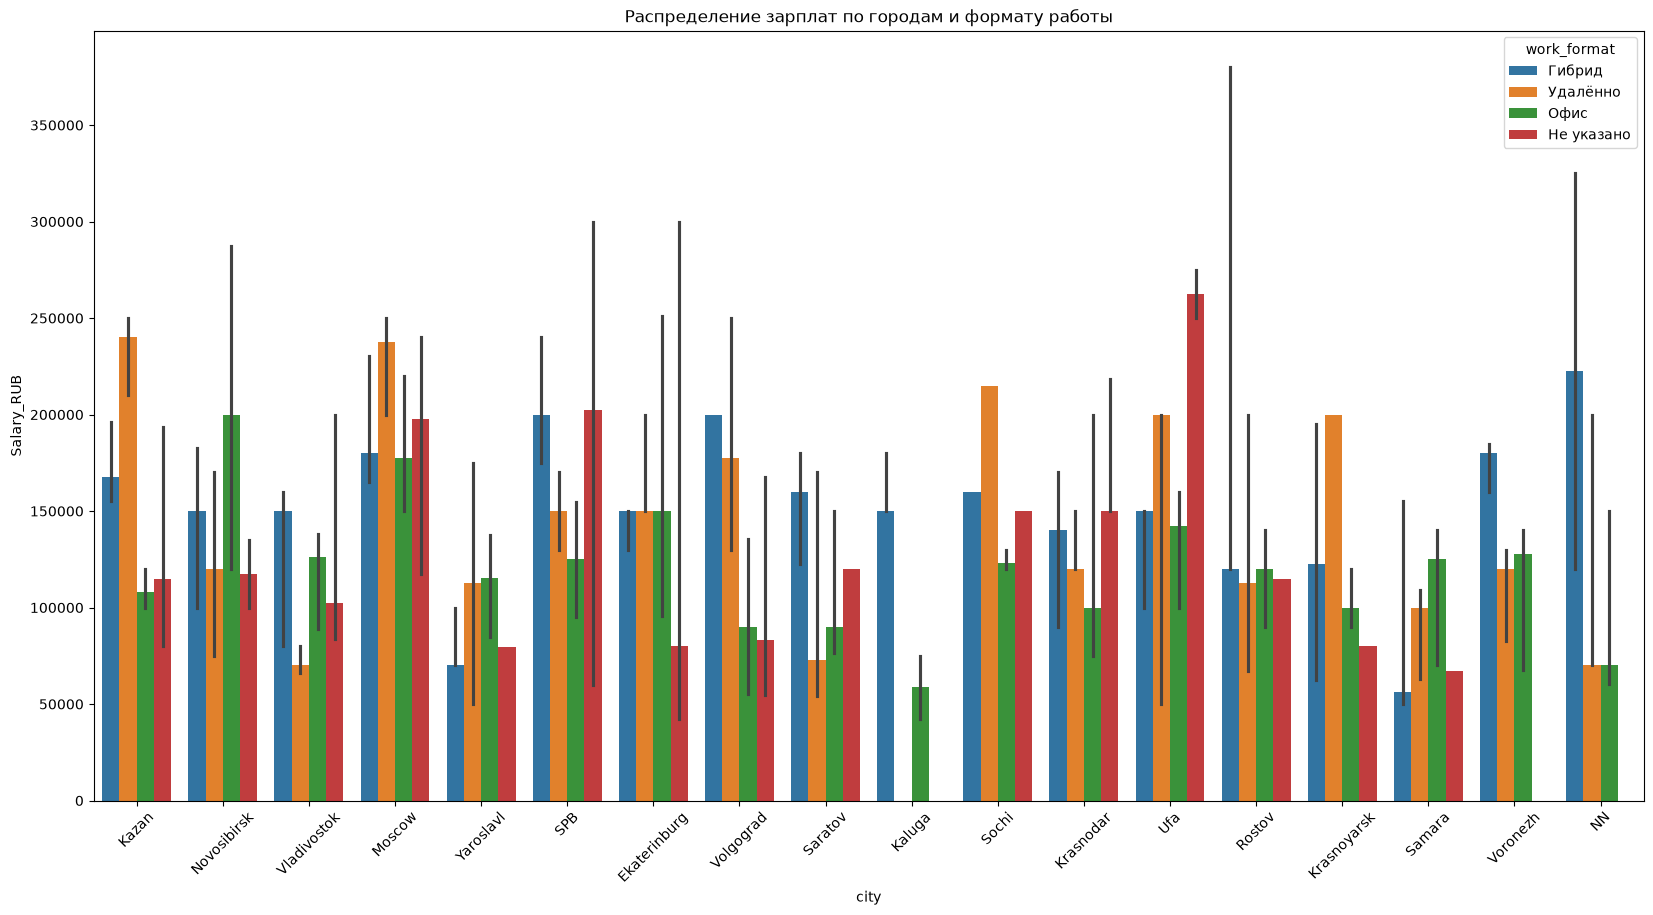

In [937]:
plt.figure(figsize=(20, 10))
sns.barplot(x='city', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_format')
plt.title('Распределение зарплат по городам и формату работы')
plt.xticks(rotation=45)
plt.show()

In [938]:
train_df.groupby(['city', 'work_format'])['Salary_RUB'].agg(['count', 'mean', 'median', 'std']).sort_values(by='count', ascending=False)

count           mean     median            std
city    work_format                                                
Kazan   Удалённо       295  250491.016949  240000.00  134050.264188
        Офис           230  133786.514348  108022.65   79777.724796
Moscow  Удалённо       182  234639.406593  237500.00  105247.471275
Kazan   Гибрид         118  182538.771186  167500.00   88378.409193
Moscow  Офис            62  190483.870968  177500.00   93245.092507
...                    ...            ...        ...            ...
Sochi   Удалённо         1  215000.000000  215000.00            NaN
Samara  Не указано       1   67000.000000   67000.00            NaN
Sochi   Не указано       1  150000.000000  150000.00            NaN
        Гибрид           1  160000.000000  160000.00            NaN
Saratov Не указано       1  120000.000000  120000.00            NaN

[68 rows x 4 columns]

In [939]:
train_df[train_df['city'] == 'Kazan'].groupby('work_format')['Salary_RUB'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
work_format,,,,
Гибрид,118,182538.771186,167500.00,88378.409193
Не указано,30,154735.000000,115000.00,105975.079333
Офис,230,133786.514348,108022.65,79777.724796
Удалённо,295,250491.016949,240000.00,134050.264188


In [940]:
train_df['Kazan_Remote'] = ((train_df['city'] == 'Kazan') & (train_df['work_format'] == 'Удалённо')).astype(int)

In [941]:
train_df[train_df['city'] == 'Moscow'].groupby('work_format')['Salary_RUB'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
work_format,,,,
Гибрид,52,218120.192308,180000.0,115534.218367
Не указано,8,175000.000000,197500.0,67875.937247
Офис,62,190483.870968,177500.0,93245.092507
Удалённо,182,234639.406593,237500.0,105247.471275


In [942]:
train_df['Moscow_Remote'] = ((train_df['city'] == 'Moscow') & (train_df['work_format'] == 'Удалённо')).astype(int)

In [943]:
train_df[train_df['city'] == 'SPB'].groupby('work_format')['Salary_RUB'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
work_format,,,,
Гибрид,42,216845.238095,200000.0,85897.449357
Не указано,8,222875.000000,202500.0,168388.528198
Офис,32,135787.500000,125000.0,62880.710156
Удалённо,35,156435.714286,150000.0,78361.045593


In [944]:
train_df.groupby(['Other_City', 'work_format'])['Salary_RUB'].agg(['count', 'mean', 'median', 'std'])

count           mean    median            std
Other_City work_format                                               
0          Гибрид         281  188196.886121  170000.0   91693.868639
           Не указано      68  164056.617647  145000.0  103930.363420
           Офис           418  149370.330861  121000.0   88691.723360
           Удалённо       556  232168.564748  200000.0  121937.416190
1          Гибрид          48  152416.666667  150000.0   86948.831451
           Не указано      12  104958.333333   86750.0   38324.842604
           Офис           170  123229.535294  120000.0   71733.881343
           Удалённо        47  106690.957447   85000.0   50946.166554

In [945]:
train_df['SmallCity_Office'] = ((train_df['Other_City'] == 1) & (train_df['work_format'] == 'Офис')).astype(int)

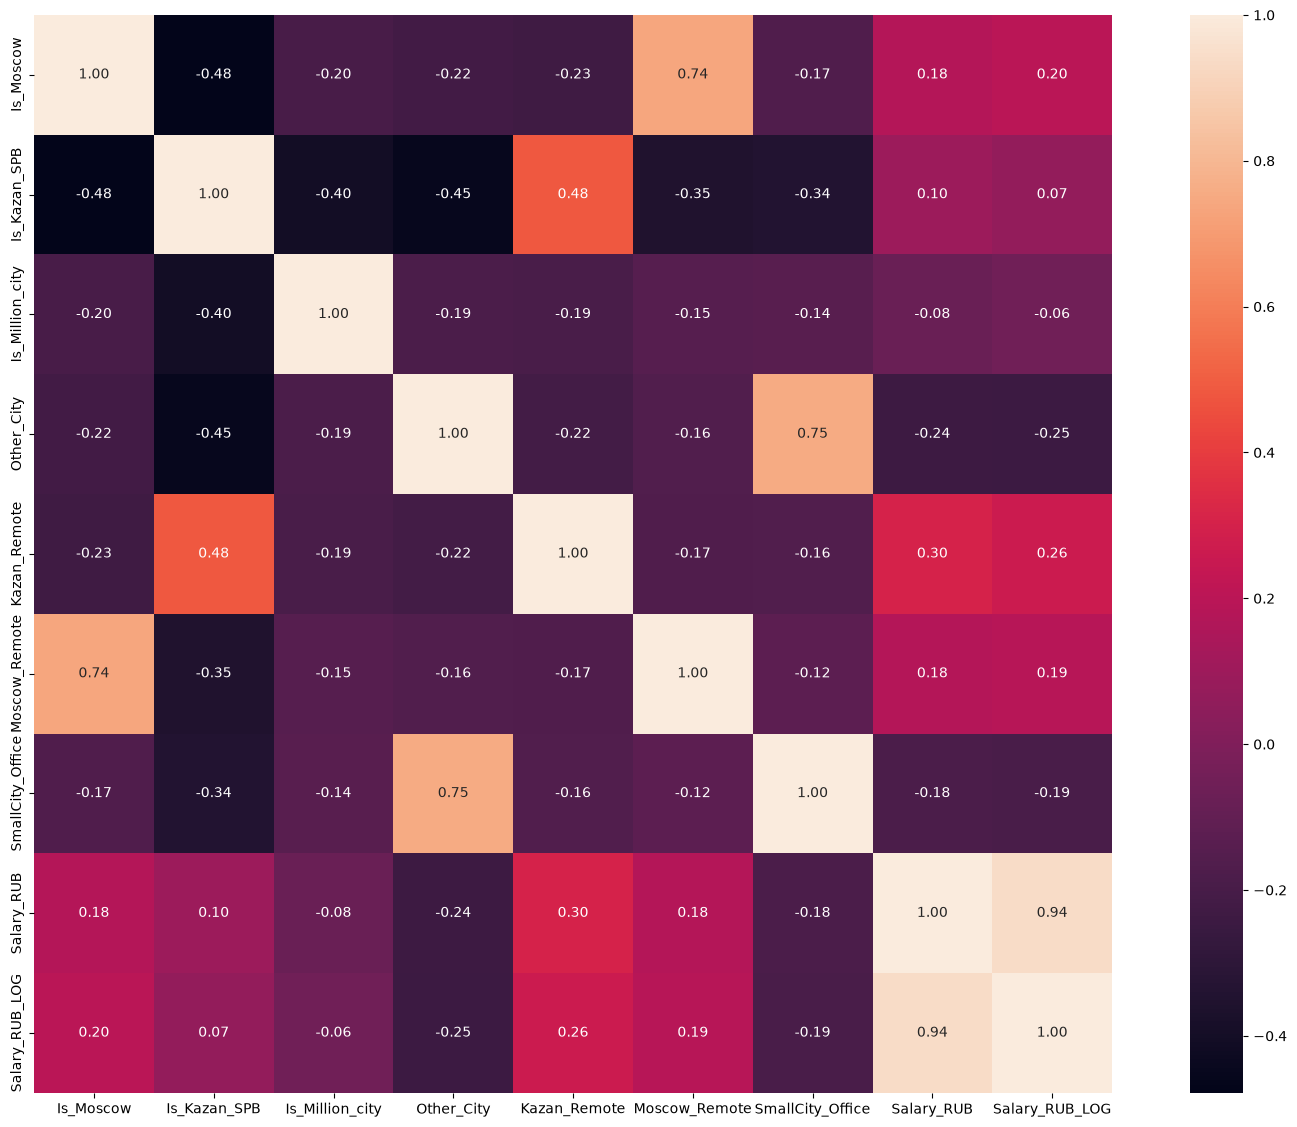

In [946]:
new_columns = ['Is_Moscow', 'Is_Kazan_SPB', 'Is_Million_city', 'Other_City', 'Kazan_Remote', 'Moscow_Remote', 'SmallCity_Office', 'Salary_RUB', 'Salary_RUB_LOG']
matrix_with_new_col = train_df[new_columns].corr()

plt.figure(figsize=(20, 14))
sns.heatmap(matrix_with_new_col, square=True, annot=True, fmt='.2f')
plt.show()

<h1>Применение к валидации</h1>

In [947]:
val_df['Is_Moscow'] = (val_df['city'] == 'Moscow').astype(int)
val_df['Is_Kazan_SPB'] = (val_df['city'].isin(['Kazan', 'SPB'])).astype(int)
val_df['Is_Million_city'] = (val_df['city'].isin(['Ekaterinburg', 'Novosibirsk', 'Krasnodar', 'Ufa', 'Volgograd'])).astype(int)
val_df['Other_City'] = (~val_df['city'].isin(['Moscow', 'Kazan', 'SPB', 'Ekaterinburg', 'Novosibirsk', 'Krasnodar', 'Ufa', 'Volgograd'])).astype(int)

val_df.drop('address', axis=1, inplace=True)

val_df['Kazan_Remote'] = ((val_df['city'] == 'Kazan') & (val_df['work_format'] == 'Удалённо')).astype(int)

val_df['Moscow_Remote'] = ((val_df['city'] == 'Moscow') & (val_df['work_format'] == 'Удалённо')).astype(int)

val_df['SmallCity_Office'] = ((val_df['Other_City'] == 1) & (val_df['work_format'] == 'Офис')).astype(int)

<h1>Второй вызов с созданными фичами, связанные с городами</h1>

In [948]:
models = [LinearRegression(), Ridge(), Lasso(), KNeighborsRegressor()]
models_names = ['LinearRegression', 'Ridge', 'Lasso', 'KNeighborsRegressor()']

numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

final_train_df = train_df[numeric_cols]
final_val_df = val_df[numeric_cols]

X_train = final_train_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_train = final_train_df['Salary_RUB_LOG']
X_val = final_val_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_val = final_val_df['Salary_RUB_LOG']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    y_pred_original = np.expm1(y_pred_log)
    y_val_original = np.expm1(y_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_original, y_pred_original):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_original, y_pred_original):.2f}")
    print()

Модель - LinearRegression
Метрики: 
Средняя абсолютная ошибка (MAE) = 56044.56
Коэффициент детерминации (RMSE) = 0.53

Модель - Ridge
Метрики: 
Средняя абсолютная ошибка (MAE) = 56097.59
Коэффициент детерминации (RMSE) = 0.53

Модель - Lasso
Метрики: 
Средняя абсолютная ошибка (MAE) = 87750.97
Коэффициент детерминации (RMSE) = -0.05

Модель - KNeighborsRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 59623.64
Коэффициент детерминации (RMSE) = 0.45



In [949]:
models = [DecisionTreeRegressor(), RandomForestRegressor(), GradientBoostingRegressor()]
models_names = ['DecisionTreeRegressor()', 'RandomForestRegressor()', 'GradientBoostingRegressor()']

y_train_orig = final_train_df['Salary_RUB']
y_val_orig = final_val_df['Salary_RUB']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train_orig)
    y_pred = model.predict(X_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_orig, y_pred):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_orig, y_pred):.2f}")
    print()

Модель - DecisionTreeRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 54988.41
Коэффициент детерминации (RMSE) = 0.52

Модель - RandomForestRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 53953.71
Коэффициент детерминации (RMSE) = 0.56

Модель - GradientBoostingRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 54301.97
Коэффициент детерминации (RMSE) = 0.57



<h1>Создание новых фичей</h1>

In [951]:
train_df[train_df['title'].str.contains('Senior')]['Salary_RUB'].median()

np.float64(288750.0)

In [952]:
train_df['Salary_RUB'].median()

np.float64(150000.0)

In [953]:
train_df[train_df['title'].str.contains('Junior', case=False, na=False)]['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count       149.000000
median    80000.000000
mean      91129.865772
std       41775.299795
Name: Salary_RUB, dtype: float64

In [954]:
train_df[train_df['title'].str.contains('Middle', case=False, na=False)]['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count        340.000000
median    165000.000000
mean      170123.014706
std        62965.626785
Name: Salary_RUB, dtype: float64

In [955]:
train_df[train_df['title'].str.contains('Ведущий', case=False, na=False)]['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count         97.000000
median    175000.000000
mean      179304.288660
std        90891.343994
Name: Salary_RUB, dtype: float64

In [956]:
train_df[train_df['title'].str.contains('Lead', case=False, na=False)]['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

count         92.000000
median    290000.000000
mean      313573.369565
std        79655.079738
Name: Salary_RUB, dtype: float64

In [957]:
def level_it_skills(title):
    title_lower = title.lower()
    title_list = title_lower.split(" ")

    if 'junior' in title_list:
        return 1
    elif 'middle' in title_list or 'ведущий' in title_list:
        return 2
    elif 'senior' in title_list or 'lead' in title_list:
        return 3
    else:
        return 0

In [958]:
train_df['Level_It_Skills'] = train_df['title'].apply(level_it_skills)

In [959]:
train_df.groupby('Level_It_Skills')['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
Level_It_Skills,,,,
0,1012,137750.0,151572.801680,86046.554742
1,78,75000.0,83517.307692,29350.598820
2,224,177500.0,180002.861607,72957.679431
3,286,300000.0,314244.842657,108901.293961


In [961]:
def categorize_role(title):
    title_lower = title.lower()

    if any(word in title_lower for word in [
        'ml engineer', 'machine learning engineer', 'ml-инженер', 'nlp', 'computer vision', 'cv',
        'ml инженер', 'ml разработчик', 'ml/llm', 'genai', 'ai engineer']):
        return 'ML Engineer'

    elif any(word in title_lower for word in ['data scientist', 'data science', 'дата сайентист', 'дата саентист', 'scientist']):
        return 'Data Scientist'

    elif any(word in title_lower for word in ['data engineer', 'дата инженер', 'big data']):
        return 'Data Engineer'

    elif any(word in title_lower for word in ['data analyst', 'data analysis', 'аналитик данных', 'аналитик дата', 'analytics', 'product analyst']):
        return 'Data Analyst'

    elif any(word in title_lower for word in ['backend', 'бэкенд', 'back-end', 'back end']):
        return 'Backend'

    elif any(word in title_lower for word in [
        'frontend', 'фронтенд', 'front-end', 'front end',
        'react', 'angular', 'vue', 'javascript', 'typescript',
        'html', 'css', 'web-разработчик']):
        return 'Frontend'

    elif any(word in title_lower for word in ['fullstack', 'фуллстак', 'full-stack', 'full stack']):
        return 'Fullstack'

    elif any(word in title_lower for word in ['system administrator', 'sysadmin', 'системный администратор', 'администратор', 'linux']):
        return 'Системный администратор'

    elif any(word in title_lower for word in ['qa', 'тестировщик', 'test engineer', 'tester', 'автотестировщик', 'automation', 'quality assurance']):
        return 'QA'

    elif any(word in title_lower for word in ['project manager', 'product manager', 'pm', 'проджект', 'продакт', 'team lead', 'tech lead', 'руководитель', 'менеджер']):
        return 'Management'

    elif any(word in title_lower for word in ['1с', '1c', 'битрикс', 'bitrix']):
        return '1C/Bitrix'

    else:
        return 'Other'

In [962]:
train_df['Role_Category'] = train_df['title'].apply(categorize_role)

In [963]:
train_df.groupby('Role_Category')['Salary_RUB'].agg(['count', 'mean', 'median', 'std']).sort_values(by='median', ascending=False)

,count,mean,median,std
Role_Category,,,,
ML Engineer,55,247617.272727,300000.0,130748.028531
Data Scientist,67,282227.238806,290000.0,71995.800689
Data Engineer,34,233786.764706,245000.0,100552.208894
Backend,161,230397.360248,200000.0,142147.783893
Frontend,142,197082.394366,178550.0,101633.329995
Fullstack,105,193345.714286,177100.0,103375.656243
Management,51,234366.666667,177100.0,140783.755337
Other,496,179854.959677,154000.0,101183.638079
QA,119,137300.420168,150000.0,60247.458451


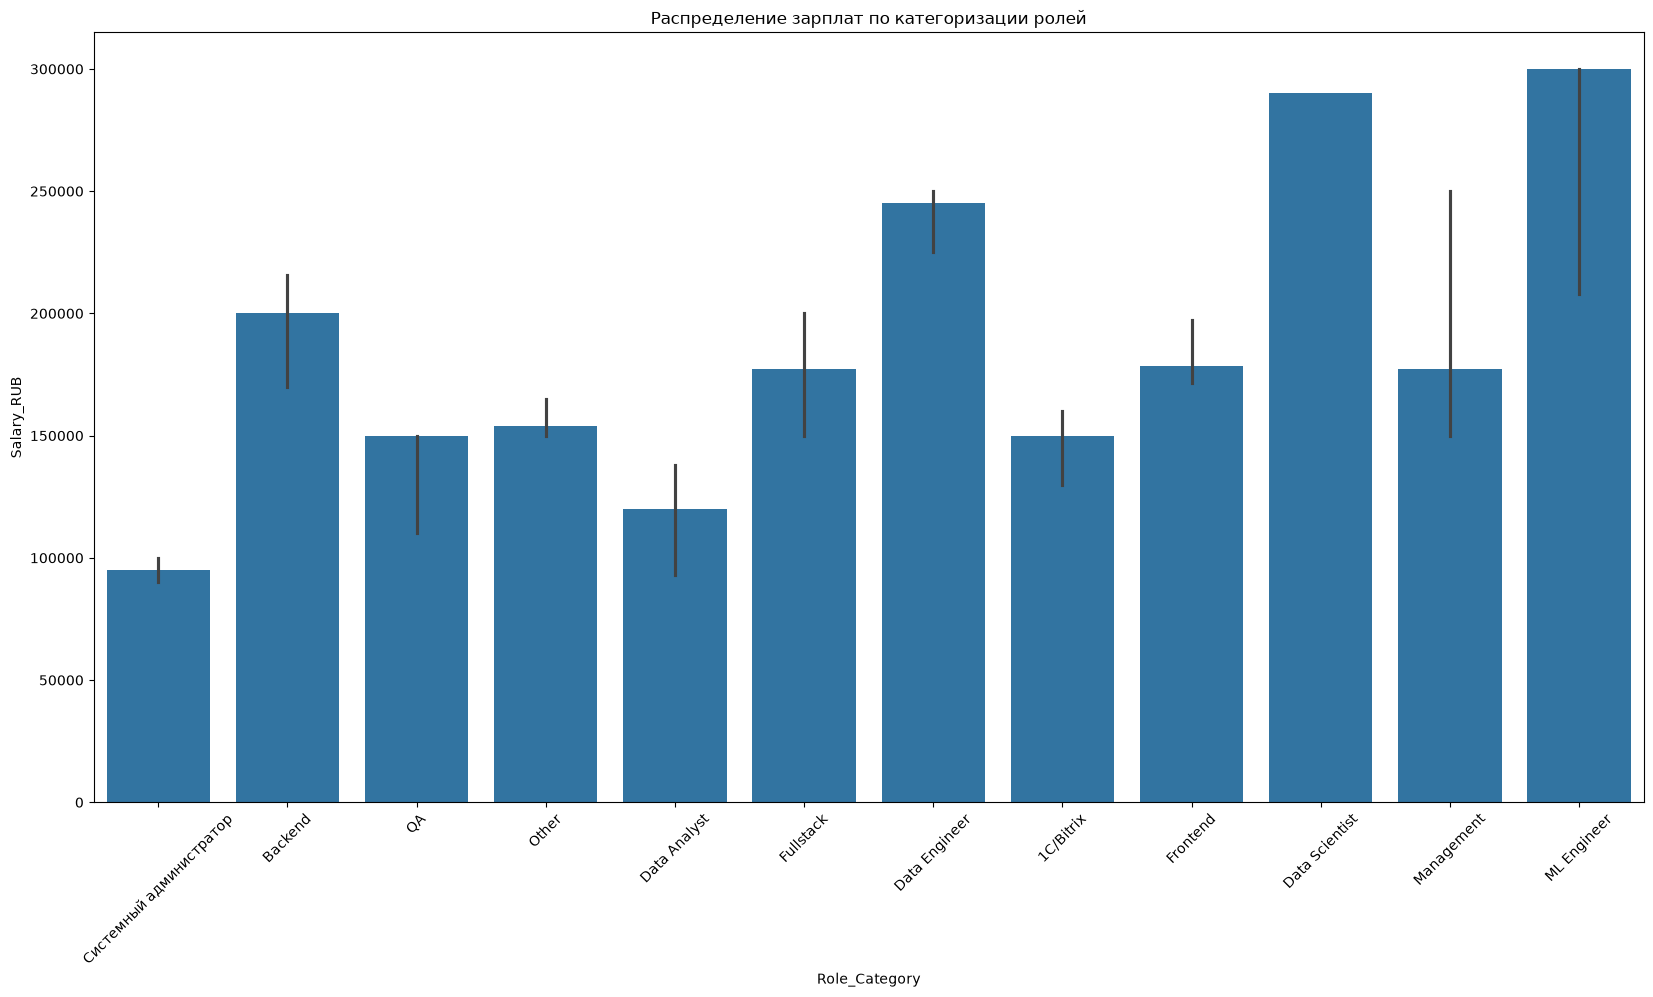

In [964]:
plt.figure(figsize=(20, 10))
sns.barplot(x='Role_Category', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по категоризации ролей')
plt.xticks(rotation=45)
plt.show()

In [965]:
def regroup_role(role):
    if role in ['ML Engineer', 'Data Scientist', 'Data Engineer']:
        return 'ML/Data'
    elif role in ['Backend', 'Frontend', 'Fullstack', 'Management']:
        return 'Developer/Manager'
    elif role == 'Системный администратор':
        return 'Системный администратор'
    else:
        return 'Other'

In [966]:
train_df['Role_Group'] = train_df['Role_Category'].apply(regroup_role)

In [967]:
train_df.groupby('Role_Group')['Salary_RUB'].agg(['count', 'median', 'mean'])

,count,median,mean
Role_Group,,,
Developer/Manager,459,180000.0,212055.936819
ML/Data,156,290000.0,259467.467949
Other,762,150000.0,168963.687664
Системный администратор,223,95000.0,105559.467713


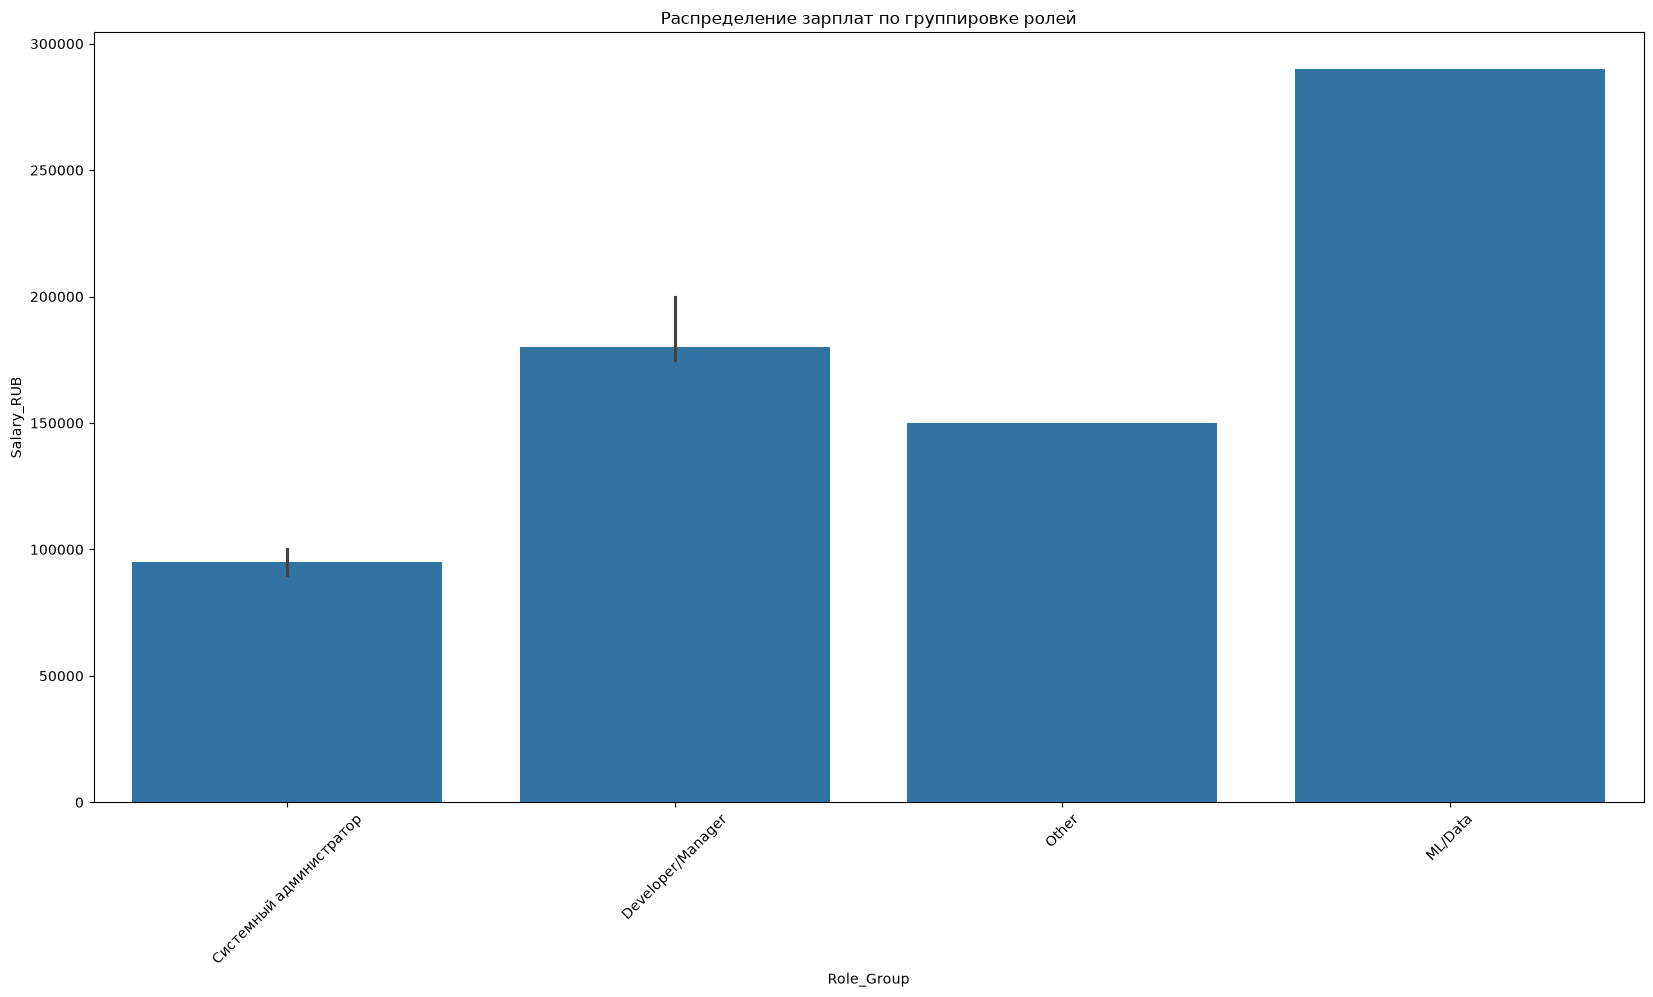

In [968]:
plt.figure(figsize=(20, 10))
sns.barplot(x='Role_Group', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по группировке ролей')
plt.xticks(rotation=45)
plt.show()

In [969]:
group_mapping = {
    'Системный администратор': 0,
    'Other': 1,
    'Developer/Manager': 2,
    'ML/Data': 3
}

In [970]:
train_df['Role_Level'] = train_df['Role_Group'].map(group_mapping)

In [971]:
train_df.drop('Role_Category', axis=1, inplace=True)

In [972]:
train_df.groupby(['Role_Group', 'work_format'])['Salary_RUB'].agg(['count', 'mean', 'median'])

count           mean    median
Role_Group              work_format                                
Developer/Manager       Гибрид         102  194498.529412  175000.0
                        Не указано      14  142321.428571  150000.0
                        Офис           108  173050.462963  150000.0
                        Удалённо       235  241756.914894  211750.0
ML/Data                 Гибрид          15  255595.000000  207900.0
                        Не указано       3  300000.000000  300000.0
                        Офис            58  241939.655172  290000.0
                        Удалённо        80  271381.250000  300000.0
Other                   Гибрид         193  174365.544041  150000.0
                        Не указано      37  195978.378378  200000.0
                        Офис           255  133057.874510  120000.0
                        Удалённо       277  194645.566787  175000.0
Системный администратор Гибрид          19  151263.157895  150000.0
                        Не указано      26   87371.153846   81750.0
                        Офис           167  100204.259281   90000.0
                        Удалённо        11  150909.090909  130000.0

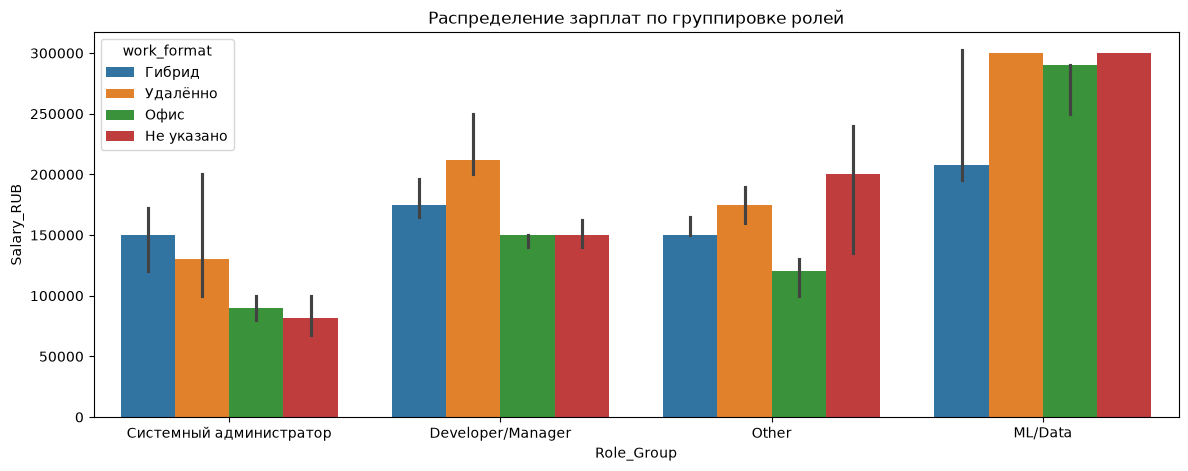

In [973]:
plt.figure(figsize=(14, 5))
sns.barplot(x='Role_Group', y='Salary_RUB', data=train_df, estimator=np.median, hue='work_format')
plt.title('Распределение зарплат по группировке ролей')
plt.show()

In [974]:
train_df['Other_Office'] = ((train_df['Role_Group'] == 'Other') & (train_df['work_format'] == 'Офис')).astype(int)

In [975]:
train_df.groupby('Other_Office')['Salary_RUB'].agg(['count', 'median', 'mean'])

,count,median,mean
Other_Office,,,
0,1345,165000.0,190461.660446
1,255,120000.0,133057.874510


In [976]:
train_df.groupby('count_payments')['Salary_RUB'].agg(['count', 'median', 'mean', 'std']).sort_values(by='median', ascending=False)

,count,median,mean,std
count_payments,,,,
Раз в месяц,165,200000.0,214367.272727,130764.648209
Не указано,546,165000.0,186277.454762,107115.806750
Два раза в месяц,862,150000.0,172240.836427,102431.148081
За проект,9,120000.0,167222.222222,136109.126970
Раз в неделю,18,107500.0,169222.222222,134057.738024


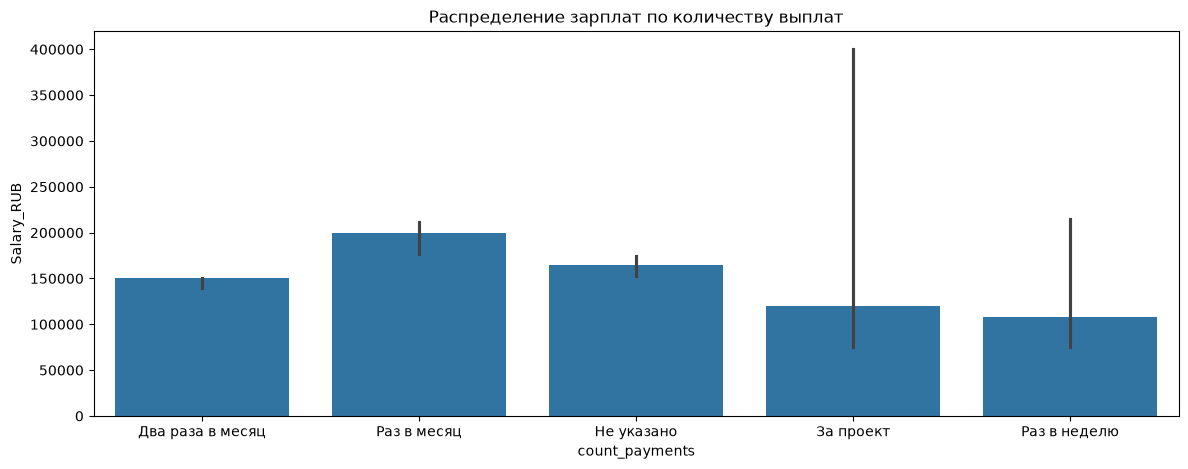

In [977]:
plt.figure(figsize=(14, 5))
sns.barplot(x='count_payments', y='Salary_RUB', data=train_df, estimator=np.median)
plt.title('Распределение зарплат по количеству выплат')
plt.show()

In [978]:
train_df['Payment_Monthly'] = (train_df['count_payments'] == 'Раз в месяц').astype(int)

In [979]:
train_df.groupby('Payment_Monthly')['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
Payment_Monthly,,,,
0,1435,150000.0,177512.258746,104996.392852
1,165,200000.0,214367.272727,130764.648209


In [980]:
train_df.drop(['Role_Group', 'count_payments'], axis=1, inplace=True)

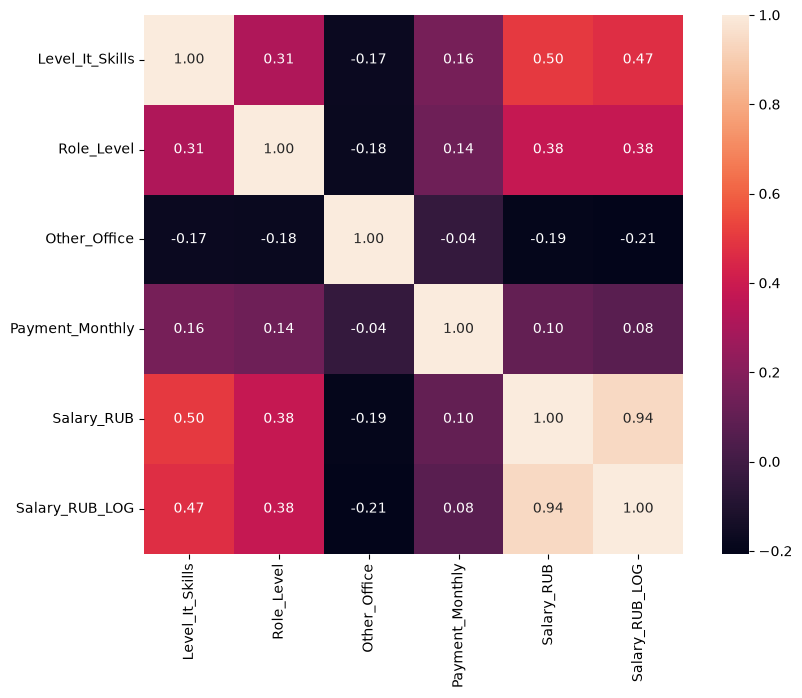

In [981]:
new_cols = ['Level_It_Skills', 'Role_Level', 'Other_Office', 'Payment_Monthly', 'Salary_RUB', 'Salary_RUB_LOG']
matrix = train_df[new_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(matrix, square=True, annot=True, fmt='.2f')
plt.show()

In [982]:
val_df['Level_It_Skills'] = val_df['title'].apply(level_it_skills)

val_df['Role_Category'] = val_df['title'].apply(categorize_role)

val_df['Role_Group'] = val_df['Role_Category'].apply(regroup_role)

val_df['Role_Level'] = val_df['Role_Group'].map(group_mapping)

val_df.drop('Role_Category', axis=1, inplace=True)

val_df['Other_Office'] = ((val_df['Role_Group'] == 'Other') & (val_df['work_format'] == 'Офис')).astype(int)

val_df.drop('name_company', axis=1, inplace=True)

val_df['Payment_Monthly'] = (val_df['count_payments'] == 'Раз в месяц').astype(int)

val_df.drop(['Role_Group', 'count_payments'], axis=1, inplace=True)


<h1>Третий вызов с созданными фичами</h1>

In [983]:
models = [LinearRegression(), Ridge(), Lasso(), KNeighborsRegressor()]
models_names = ['LinearRegression', 'Ridge', 'Lasso', 'KNeighborsRegressor()']

numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

final_train_df = train_df[numeric_cols]
final_val_df = val_df[numeric_cols]

X_train = final_train_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_train = final_train_df['Salary_RUB_LOG']
X_val = final_val_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_val = final_val_df['Salary_RUB_LOG']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    y_pred_original = np.expm1(y_pred_log)
    y_val_original = np.expm1(y_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_original, y_pred_original):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_original, y_pred_original):.2f}")
    print()

Модель - LinearRegression
Метрики: 
Средняя абсолютная ошибка (MAE) = 52536.33
Коэффициент детерминации (RMSE) = 0.57

Модель - Ridge
Метрики: 
Средняя абсолютная ошибка (MAE) = 52570.61
Коэффициент детерминации (RMSE) = 0.57

Модель - Lasso
Метрики: 
Средняя абсолютная ошибка (MAE) = 87750.97
Коэффициент детерминации (RMSE) = -0.05

Модель - KNeighborsRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 47902.11
Коэффициент детерминации (RMSE) = 0.61



In [984]:
models = [DecisionTreeRegressor(), RandomForestRegressor(), GradientBoostingRegressor()]
models_names = ['DecisionTreeRegressor()', 'RandomForestRegressor()', 'GradientBoostingRegressor()']

y_train_orig = final_train_df['Salary_RUB']
y_val_orig = final_val_df['Salary_RUB']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train_orig)
    y_pred = model.predict(X_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_orig, y_pred):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_orig, y_pred):.2f}")
    print()

Модель - DecisionTreeRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 44873.17
Коэффициент детерминации (RMSE) = 0.63

Модель - RandomForestRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 44767.00
Коэффициент детерминации (RMSE) = 0.65

Модель - GradientBoostingRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 47843.23
Коэффициент детерминации (RMSE) = 0.65



<h1>Работа с полем Skills</h1>

In [985]:
import ast

def str_to_list(skill_str):
    try:
        return ast.literal_eval(skill_str)
    except:
        return []

In [986]:
train_df['skills'] = train_df['skills'].apply(str_to_list)

In [987]:
mask = train_df['skills'].apply(lambda x: x == ['Не указано'])
train_df[mask]['Salary_RUB'].median()

np.float64(150000.0)

In [988]:
mask2 = train_df['skills'].apply(lambda x: x != ['Не указано'])
train_df[mask2]['Salary_RUB'].median()

np.float64(150000.0)

In [989]:
popular_programming_languages = ['python', 'php', 'kotlin', 'swift', 'java', 'golang', 'go']

In [990]:
def has_any_lang(skills):
    skills_lower = [s.lower() for s in skills]
    return int(any(lang in ' '.join(skills_lower) for lang in popular_programming_languages))

In [991]:
train_df['Has_Program_Lang'] = train_df['skills'].apply(has_any_lang).astype(int)

In [992]:
train_df['Has_Program_Lang'].value_counts()

Has_Program_Lang
0    1014
1     586
Name: count, dtype: int64

In [993]:
train_df.groupby('Has_Program_Lang')['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
Has_Program_Lang,,,,
0,1014,150000.0,163402.042406,96244.420027
1,586,200000.0,212305.495392,120841.041344


In [994]:
def count_skills(skills):
    if skills == ['Не указано']:
        return 0
    return len(skills)

In [995]:
train_df['Skills_Count'] = train_df['skills'].apply(count_skills)

In [997]:
train_df.groupby('Skills_Count')['Salary_RUB'].agg(['count', 'median', 'mean', 'std']).sort_values(by='median', ascending=False)

,count,median,mean,std
Skills_Count,,,,
20,10,450000.0,429300.000000,43639.431710
26,1,320000.0,320000.000000,NaN
1,71,290000.0,247297.183099,113079.171976
25,3,280000.0,276666.666667,5773.502692
13,37,240000.0,233351.351351,121100.530143
18,7,230000.0,195500.000000,77465.583756
21,19,200000.0,228418.421053,126593.756385
11,65,200000.0,206316.923077,136084.515983
12,69,165000.0,190461.956522,113985.464002


In [998]:
high_skill_counts = [1, 11, 13, 20, 21]

In [999]:
train_df['Is_High_Skills'] = train_df['Skills_Count'].isin(high_skill_counts).astype(int)

In [1000]:
train_df.groupby('Is_High_Skills')['Salary_RUB'].agg(['count', 'median', 'mean', 'std'])

,count,median,mean,std
Is_High_Skills,,,,
0,1398,150000.0,173007.897926,102567.921369
1,202,240000.0,238790.346535,129169.137304


In [1001]:
val_df['skills'] = val_df['skills'].apply(str_to_list)

val_df['Has_Program_Lang'] = val_df['skills'].apply(has_any_lang).astype(int)

val_df['Skills_Count'] = val_df['skills'].apply(count_skills)

val_df['Is_High_Skills'] = val_df['Skills_Count'].isin(high_skill_counts).astype(int)

<h1>Четвертый вызов с созданными фичами, связанные с skills</h1>

In [1002]:
models = [LinearRegression(), Ridge(), Lasso(), KNeighborsRegressor()]
models_names = ['LinearRegression', 'Ridge', 'Lasso', 'KNeighborsRegressor()']

numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

final_train_df = train_df[numeric_cols]
final_val_df = val_df[numeric_cols]

X_train = final_train_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_train = final_train_df['Salary_RUB_LOG']
X_val = final_val_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_val = final_val_df['Salary_RUB_LOG']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    y_pred_original = np.expm1(y_pred_log)
    y_val_original = np.expm1(y_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_original, y_pred_original):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_original, y_pred_original):.2f}")
    print()

Модель - LinearRegression
Метрики: 
Средняя абсолютная ошибка (MAE) = 52845.04
Коэффициент детерминации (RMSE) = 0.57

Модель - Ridge
Метрики: 
Средняя абсолютная ошибка (MAE) = 52865.62
Коэффициент детерминации (RMSE) = 0.57

Модель - Lasso
Метрики: 
Средняя абсолютная ошибка (MAE) = 87750.97
Коэффициент детерминации (RMSE) = -0.05

Модель - KNeighborsRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 49020.67
Коэффициент детерминации (RMSE) = 0.57



In [1003]:
models = [DecisionTreeRegressor(), RandomForestRegressor(), GradientBoostingRegressor()]
models_names = ['DecisionTreeRegressor()', 'RandomForestRegressor()', 'GradientBoostingRegressor()']

y_train_orig = final_train_df['Salary_RUB']
y_val_orig = final_val_df['Salary_RUB']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train_orig)
    y_pred = model.predict(X_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_orig, y_pred):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_orig, y_pred):.2f}")

    importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(importances.head(10))
    print()

Модель - DecisionTreeRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 30290.51
Коэффициент детерминации (RMSE) = 0.73
             feature  importance
26   Level_It_Skills    0.357262
0          Exp_Label    0.186078
31      Skills_Count    0.098078
27        Role_Level    0.078754
30  Has_Program_Lang    0.032575
32    Is_High_Skills    0.032543
29   Payment_Monthly    0.025888
22        Other_City    0.019883
20      Is_Kazan_SPB    0.018481
23      Kazan_Remote    0.017061

Модель - RandomForestRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 34917.04
Коэффициент детерминации (RMSE) = 0.75
             feature  importance
26   Level_It_Skills    0.282506
0          Exp_Label    0.248010
31      Skills_Count    0.118931
27        Role_Level    0.072982
30  Has_Program_Lang    0.029991
29   Payment_Monthly    0.024243
23      Kazan_Remote    0.020543
22        Other_City    0.019119
32    Is_High_Skills    0.018074
14   Senior_Fulltime    0.016708

Модель - GradientBoost

<h1>Добавление векторизации к колонке Skills</h1>

In [1005]:
print(train_df['skills'].dtype)

object


In [1006]:
type(train_df['skills'].iloc[0])

list

In [1007]:
skills_list = train_df['skills'].tolist()

In [1008]:
w2v = Word2Vec(
    sentences=skills_list,
    vector_size=100,
    window=5,
    min_count=3,
    workers=6,
    sg=1
)

In [1009]:
w2v.wv.most_similar('Git')

[('React', 0.9966450333595276),
 ('TypeScript', 0.9961954355239868),
 ('Веб-программирование', 0.9961529970169067),
 ('PostgreSQL', 0.9959936738014221),
 ('MySQL', 0.9959836602210999),
 ('MongoDB', 0.9959833025932312),
 ('Node.js', 0.9959592819213867),
 ('Docker', 0.9958844184875488),
 ('SQL', 0.9957234263420105),
 ('API', 0.9955996870994568)]

In [1010]:
w2v.wv.most_similar('Python')

[('FastAPI', 0.9960818290710449),
 ('Kubernetes', 0.9958885312080383),
 ('MongoDB', 0.9958762526512146),
 ('Docker', 0.9958353638648987),
 ('SQL', 0.9958261847496033),
 ('Celery', 0.9957841038703918),
 ('PostgreSQL', 0.9957758784294128),
 ('Clickhouse', 0.9954921007156372),
 ('REST API', 0.9954695105552673),
 ('Node.js', 0.9954579472541809)]

In [1011]:
w2v.wv.most_similar('Linux')

[('Kafka', 0.9974615573883057),
 ('REST', 0.9973250031471252),
 ('Go', 0.9973052740097046),
 ('Gitlab', 0.9970259070396423),
 ('Английский язык', 0.9970163702964783),
 ('Apache HTTP Server', 0.9970141649246216),
 ('ASP.NET', 0.9969556331634521),
 ('Администрирование сайтов', 0.9969402551651001),
 ('Работа в команде', 0.9969258308410645),
 ('SOAR', 0.9968996644020081)]

In [1012]:
def skills_vector(skills):
    vectors = [w2v.wv[skill] for skill in skills if skill in w2v.wv and skill != "Не указано"]
    if not vectors:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

In [1013]:
all_vectors_skills = [skills_vector(skills) for skills in skills_list]

In [1014]:
skills_vector_df = pd.DataFrame(
    all_vectors_skills,
    columns=[f"Skill_Vector_{i}" for i in range(100)],
    index=train_df.index
)

train_df = pd.concat([train_df, skills_vector_df], axis=1)

In [1015]:
val_vectors = [skills_vector(skills) for skills in val_df['skills']]

val_vectors_df = pd.DataFrame(
    val_vectors,
    columns=[f'Skill_Vector_{i}' for i in range(100)],
    index=val_df.index
)

val_df = pd.concat([val_df, val_vectors_df], axis=1)

<h1>Пятый вызов с применением векторизации</h1>

In [1016]:
models = [LinearRegression(), Ridge(), Lasso(), KNeighborsRegressor()]
models_names = ['LinearRegression', 'Ridge', 'Lasso', 'KNeighborsRegressor()']

numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

final_train_df = train_df[numeric_cols]
final_val_df = val_df[numeric_cols]

X_train = final_train_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_train = final_train_df['Salary_RUB_LOG']
X_val = final_val_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_val = final_val_df['Salary_RUB_LOG']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    y_pred_original = np.expm1(y_pred_log)
    y_val_original = np.expm1(y_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_original, y_pred_original):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_original, y_pred_original):.2f}")
    print()

Модель - LinearRegression
Метрики: 
Средняя абсолютная ошибка (MAE) = 48716.74
Коэффициент детерминации (RMSE) = 0.61

Модель - Ridge
Метрики: 
Средняя абсолютная ошибка (MAE) = 51999.46
Коэффициент детерминации (RMSE) = 0.57

Модель - Lasso
Метрики: 
Средняя абсолютная ошибка (MAE) = 87750.97
Коэффициент детерминации (RMSE) = -0.05

Модель - KNeighborsRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 49090.55
Коэффициент детерминации (RMSE) = 0.58



In [1017]:
models = [DecisionTreeRegressor(), RandomForestRegressor(), GradientBoostingRegressor()]
models_names = ['DecisionTreeRegressor()', 'RandomForestRegressor()', 'GradientBoostingRegressor()']

y_train_orig = final_train_df['Salary_RUB']
y_val_orig = final_val_df['Salary_RUB']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train_orig)
    y_pred = model.predict(X_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_orig, y_pred):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_orig, y_pred):.2f}")

    importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(importances.head(10))
    print()

Модель - DecisionTreeRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 23631.02
Коэффициент детерминации (RMSE) = 0.80
             feature  importance
26   Level_It_Skills    0.345018
0          Exp_Label    0.180565
58   Skill_Vector_25    0.031073
33    Skill_Vector_0    0.030592
115  Skill_Vector_82    0.029011
92   Skill_Vector_59    0.027313
27        Role_Level    0.025206
109  Skill_Vector_76    0.020072
22        Other_City    0.016661
131  Skill_Vector_98    0.012972

Модель - RandomForestRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 29071.07
Коэффициент детерминации (RMSE) = 0.82
             feature  importance
0          Exp_Label    0.259945
26   Level_It_Skills    0.249594
27        Role_Level    0.022008
14   Senior_Fulltime    0.018528
126  Skill_Vector_93    0.017271
22        Other_City    0.014806
58   Skill_Vector_25    0.013819
109  Skill_Vector_76    0.011755
33    Skill_Vector_0    0.011228
81   Skill_Vector_48    0.011179

Модель - GradientBoost

<h1>Обработка колонки детальной информации</h1>

In [1018]:
def clean_detailed_info(text):
    text = text.lower()

    text = re.sub(r'[^а-яa-z0-9\s\.]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

train_df['detailed_information'] = train_df['detailed_information'].apply(clean_detailed_info)

In [1019]:
morph = MorphAnalyzer() # лемматизация

def lemmatize_text(text):
    words = str(text).split()
    lemmas = []

    for word in words:
        parsed = morph.parse(word)[0]
        lemmas.append(parsed.normal_form)

    return ' '.join(lemmas)

train_df['detailed_information'] = train_df['detailed_information'].apply(lemmatize_text)

In [1020]:
nltk.download('stopwords')
russian = stopwords.words('russian')
english = stopwords.words('english')

all_lang_stopwords = list(set(russian + english))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [1021]:
def remove_stopwords(text):
    words = text.split()
    filter_text = [word for word in words if word not in all_lang_stopwords]
    return ' '.join(filter_text)

train_df['detailed_information'] = train_df['detailed_information'].apply(remove_stopwords)

In [1022]:
tfidf = TfidfVectorizer(
    min_df = 5,
    max_df = 0.7,
    ngram_range = (1, 2),
    stop_words = all_lang_stopwords,
    max_features = 5000,
    lowercase=True,
    token_pattern=r'(?u)\b[a-zA-Zа-яА-Я][a-zA-Zа-яА-Я+/-]+\b'
)

tfidf_matrix = tfidf.fit_transform(train_df['detailed_information'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{col}" for col in tfidf.get_feature_names_out()],
    index=train_df.index
)

train_df = pd.concat([train_df, tfidf_df], axis=1)

<h1>Применение к валидации</h1>

In [1023]:
val_df['detailed_information'] = val_df['detailed_information'].apply(clean_detailed_info)

val_df['detailed_information'] = val_df['detailed_information'].apply(lemmatize_text)

val_df['detailed_information'] = val_df['detailed_information'].apply(remove_stopwords)

tfidf_matrix_val = tfidf.transform(val_df['detailed_information'])

tfidf_df_val = pd.DataFrame(
    tfidf_matrix_val.toarray(),
    columns=[f"tfidf_{col}" for col in tfidf.get_feature_names_out()],
    index=val_df.index
)

val_df = pd.concat([val_df, tfidf_df_val], axis=1)

<h1>Шестой цикл обучения</h1>

In [1024]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

final_train_df = train_df[numeric_cols]
final_val_df = val_df[numeric_cols]

X_train = final_train_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_train = final_train_df['Salary_RUB_LOG']
X_val = final_val_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_val = final_val_df['Salary_RUB_LOG']

In [1025]:
models = [LinearRegression(), Ridge(), KNeighborsRegressor()]
models_names = ['LinearRegression', 'Ridge', 'KNeighborsRegressor()']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    y_pred_original = np.expm1(y_pred_log)
    y_val_original = np.expm1(y_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_original, y_pred_original):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_original, y_pred_original):.2f}")
    print()

Модель - LinearRegression
Метрики: 
Средняя абсолютная ошибка (MAE) = 16051.43
Коэффициент детерминации (RMSE) = 0.87

Модель - Ridge
Метрики: 
Средняя абсолютная ошибка (MAE) = 29434.09
Коэффициент детерминации (RMSE) = 0.82

Модель - KNeighborsRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 47012.01
Коэффициент детерминации (RMSE) = 0.59



In [1026]:
models = [DecisionTreeRegressor(), RandomForestRegressor()]
models_names = ['DecisionTreeRegressor()', 'RandomForestRegressor()']

y_train_orig = final_train_df['Salary_RUB']
y_val_orig = final_val_df['Salary_RUB']

for i in range(len(models)):
    model = models[i]
    model_name = models_names[i]
    print(f"Модель - {model_name}")
    model.fit(X_train, y_train_orig)
    y_pred = model.predict(X_val)

    print("Метрики: ")
    print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_orig, y_pred):.2f}")
    print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_orig, y_pred):.2f}")

    importances = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(importances.head(10))
    print()

Модель - DecisionTreeRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 20066.38
Коэффициент детерминации (RMSE) = 0.83
                      feature  importance
26            Level_It_Skills    0.327126
0                   Exp_Label    0.186772
857           tfidf_solutions    0.041229
4668            tfidf_техника    0.027784
2848            tfidf_область    0.017037
22                 Other_City    0.015886
428        tfidf_fundamentals    0.015144
67            Skill_Vector_34    0.013531
1739  tfidf_доступность метро    0.012447
147             tfidf_airflow    0.012168

Модель - RandomForestRegressor()
Метрики: 
Средняя абсолютная ошибка (MAE) = 22572.92
Коэффициент детерминации (RMSE) = 0.88
              feature  importance
26    Level_It_Skills    0.253054
0           Exp_Label    0.231553
14    Senior_Fulltime    0.011811
211    tfidf_benefits    0.009665
857   tfidf_solutions    0.009447
2620     tfidf_модель    0.008265
22         Other_City    0.008161
4668    tfidf_т

In [1027]:
lr = LinearRegression()

LR_scores_cross = cross_val_score(lr, X_train, y_train, scoring='r2', cv=5)

print(f"R2 на каждом фолде: {LR_scores_cross}")
print(f"Средний R2: {LR_scores_cross.mean():.5f}")

R2 на каждом фолде: [0.84834724 0.76271336 0.77918612 0.80176755 0.80145004]
Средний R2: 0.79869


In [1028]:
rf = RandomForestRegressor()

RF_scores_cross = cross_val_score(rf, X_train, y_train, scoring='r2', cv=5)

print(f"R2 на каждом фолде: {RF_scores_cross}")
print(f"Средний R2: {RF_scores_cross.mean():.5f}")

R2 на каждом фолде: [0.83957341 0.78735223 0.80092681 0.84071592 0.78472587]
Средний R2: 0.81066


In [1029]:
linear_regression = LinearRegression()

linear_regression.fit(X_train, y_train)

y_pred_log = linear_regression.predict(X_val)

y_pred_original = np.expm1(y_pred_log)
y_val_original = np.expm1(y_val)

print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_original, y_pred_original):.2f}")
print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_original, y_pred_original):.2f}")

Средняя абсолютная ошибка (MAE) = 16051.43
Коэффициент детерминации (RMSE) = 0.87


In [1030]:
# rf_params = {
#     'n_estimators': [100, 150, 200, 250, 300, 400, 500],
#     'max_depth': [2, 5, 7, 10, 20, 30, None],
#     'min_samples_split': [2, 3, 5, 7, 10],
#     'min_samples_leaf': [1, 3, 5, 10],
#     'max_features': ['sqrt', 'log2', 0.25, 0.5, 0.75, None]
# }
#
# rf_model = RandomForestRegressor()
# random_forest_CV = RandomizedSearchCV(
#     estimator=rf_model,
#     param_distributions=rf_params,
#     cv=3,
#     n_jobs=-1,
#     scoring='r2',
#     n_iter=50)
#
# random_forest_CV.fit(X_train, y_train_orig)
#
# print(f"Лучшие параметры: {random_forest_CV.best_params_}")
# print(f"Лучший R² на CV: {random_forest_CV.best_score_:.5f}")
#
# y_pred = random_forest_CV.predict(X_val)
#
# print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_val_orig, y_pred):.2f}")
# print(f"Коэффициент детерминации (RMSE) = {r2_score(y_val_orig, y_pred):.2f}")

<h1>Создание признаков на тесте</h1>

In [1031]:
test_df['Exp_Label'] = test_df['experience'].map(exp_mapping)
test_df['Format_Label'] = test_df['work_format'].map(format_mapping)

test_df['Is_Full_Time'] = (test_df['common_employment'] == 'Полная занятость').astype(int)
test_df['Is_Part_Time'] = (test_df['common_employment'] == 'Частичная занятость').astype(int)

test_df['Is_Classic_Schedule'] = (test_df['work_schedule'] == 'Классический (5/2)').astype(int)

test_df['Classic_Schedule_with_Other_Hours'] = ((test_df['work_schedule'] == 'Классический (5/2)') & (test_df['work_hours'] == 'Другие')).astype(int)

test_df['Is_Flexible_Hours'] = (test_df['work_hours'] == 'По договоренности').astype(int)
test_df['Is_8_Hours'] = (test_df['work_hours'] == '8 часов').astype(int)

test_df['Medium_Exp_with_8_Hours'] = ((test_df['work_hours'] == '8 часов') & (test_df['experience'] == '3-6 лет')).astype(int)
test_df['Low_Exp_with_8_Hours'] = ((test_df['work_hours'] == '8 часов') & (test_df['experience'] == '1-3 года')).astype(int)
test_df['Zero_Exp_with_8_Hours'] = ((test_df['work_hours'] == '8 часов') & (test_df['experience'] == 'Нет опыта')).astype(int)

test_df['Remote_Senior'] = ((test_df['work_format'] == 'Удалённо') & (test_df['experience'] == '6+ лет')).astype(int)
test_df['Remote_Middle'] = ((test_df['work_format'] == 'Удалённо') & (test_df['experience'] == '3-6 лет')).astype(int)
test_df['Office_Junior'] = ((test_df['work_format'] == 'Офис') & (test_df['experience'] == '1-3 года')).astype(int)

test_df['Senior_Fulltime'] = ((test_df['experience'] == '6+ лет') & (test_df['common_employment'] == 'Полная занятость')).astype(int)

test_df['Office_Fulltime'] = ((test_df['work_format'] == 'Офис') & (test_df['common_employment'] == 'Полная занятость')).astype(int)

test_df['Classic_Remote'] = ((test_df['work_schedule'] == 'Классический (5/2)') & (test_df['work_format'] == 'Удалённо')).astype(int)

test_df['Hours_8_Hybrid'] = ((test_df['work_hours'] == '8 часов') & (test_df['work_format'] == 'Гибрид')).astype(int)
test_df['Hours_12_Office'] = ((test_df['work_hours'] == '12 часов') & (test_df['work_format'] == 'Офис')).astype(int)

test_df['Is_Moscow'] = (test_df['city'] == 'Moscow').astype(int)
test_df['Is_Kazan_SPB'] = (test_df['city'].isin(['Kazan', 'SPB'])).astype(int)
test_df['Is_Million_city'] = (test_df['city'].isin(['Ekaterinburg', 'Novosibirsk', 'Krasnodar', 'Ufa', 'Volgograd'])).astype(int)
test_df['Other_City'] = (~test_df['city'].isin(['Moscow', 'Kazan', 'SPB', 'Ekaterinburg', 'Novosibirsk', 'Krasnodar', 'Ufa', 'Volgograd'])).astype(int)

test_df.drop('address', axis=1, inplace=True)

test_df['Kazan_Remote'] = ((test_df['city'] == 'Kazan') & (test_df['work_format'] == 'Удалённо')).astype(int)

test_df['Moscow_Remote'] = ((test_df['city'] == 'Moscow') & (test_df['work_format'] == 'Удалённо')).astype(int)

test_df['SmallCity_Office'] = ((test_df['Other_City'] == 1) & (test_df['work_format'] == 'Офис')).astype(int)

test_df['Level_It_Skills'] = test_df['title'].apply(level_it_skills)

test_df['Role_Category'] = test_df['title'].apply(categorize_role)

test_df['Role_Group'] = test_df['Role_Category'].apply(regroup_role)

test_df['Role_Level'] = test_df['Role_Group'].map(group_mapping)

test_df.drop('Role_Category', axis=1, inplace=True)

test_df['Other_Office'] = ((test_df['Role_Group'] == 'Other') & (test_df['work_format'] == 'Офис')).astype(int)

test_df.drop('name_company', axis=1, inplace=True)

test_df['Payment_Monthly'] = (test_df['count_payments'] == 'Раз в месяц').astype(int)

test_df.drop(['Role_Group', 'count_payments'], axis=1, inplace=True)

test_df['skills'] = test_df['skills'].apply(str_to_list)

test_df['Has_Program_Lang'] = test_df['skills'].apply(has_any_lang).astype(int)

test_df['Skills_Count'] = test_df['skills'].apply(count_skills)

test_df['Is_High_Skills'] = test_df['Skills_Count'].isin(high_skill_counts).astype(int)

test_vectors = [skills_vector(skills) for skills in test_df['skills']]

test_vectors_df = pd.DataFrame(
    test_vectors,
    columns=[f'Skill_Vector_{i}' for i in range(100)],
    index=test_df.index
)

test_df = pd.concat([test_df, test_vectors_df], axis=1)

test_df['detailed_information'] = test_df['detailed_information'].apply(clean_detailed_info)

test_df['detailed_information'] = test_df['detailed_information'].apply(lemmatize_text)

test_df['detailed_information'] = test_df['detailed_information'].apply(remove_stopwords)

tfidf_matrix_val = tfidf.transform(test_df['detailed_information'])

tfidf_df_test = pd.DataFrame(
    tfidf_matrix_val.toarray(),
    columns=[f"tfidf_{col}" for col in tfidf.get_feature_names_out()],
    index=test_df.index
)

test_df = pd.concat([test_df, tfidf_df_test], axis=1)

In [1032]:
final_test_df = test_df[numeric_cols]

X_test = final_test_df.drop(['Salary_RUB', 'Salary_RUB_LOG'], axis=1)
y_test = final_test_df['Salary_RUB_LOG']

In [1033]:
y_pred_log = linear_regression.predict(X_test)

y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

print(f"Средняя абсолютная ошибка (MAE) на тестах = {mean_absolute_error(y_test_original, y_pred_original):.2f}")
print(f"Коэффициент детерминации (RMSE) на тестах = {r2_score(y_test_original, y_pred_original):.2f}")

Средняя абсолютная ошибка (MAE) на тестах = 19328.97
Коэффициент детерминации (RMSE) на тестах = 0.83


In [1034]:
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)

y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

print(f"Средняя абсолютная ошибка (MAE) на тестах = {mean_absolute_error(y_test_original, y_pred_original):.2f}")
print(f"Коэффициент детерминации (RMSE) на тестах = {r2_score(y_test_original, y_pred_original):.2f}")

Средняя абсолютная ошибка (MAE) на тестах = 23953.20
Коэффициент детерминации (RMSE) на тестах = 0.86


In [1035]:
X_train = pd.concat([X_train, X_val])
y_train = pd.concat([y_train, y_val])

final_linear_regression_model = LinearRegression()

final_linear_regression_model.fit(X_train, y_train)
y_pred_log_final = final_linear_regression_model.predict(X_test)

y_pred_original_final = np.expm1(y_pred_log_final)
y_test_original = np.expm1(y_test)

print("Метрики финальной модели: ")
print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_test_original, y_pred_original_final):.2f}")
print(f"Коэффициент детерминации (RMSE) = {r2_score(y_test_original, y_pred_original_final):.2f}")
print()

Метрики финальной модели: 
Средняя абсолютная ошибка (MAE) = 15289.76
Коэффициент детерминации (RMSE) = 0.88



In [1036]:
final_rf_model = RandomForestRegressor()

final_rf_model.fit(X_train, y_train)
y_pred_log_final = final_rf_model.predict(X_test)

y_pred_original_final = np.expm1(y_pred_log_final)
y_test_original = np.expm1(y_test)

print("Метрики финальной моедли: ")
print(f"Средняя абсолютная ошибка (MAE) = {mean_absolute_error(y_test_original, y_pred_original_final):.2f}")
print(f"Коэффициент детерминации (RMSE) = {r2_score(y_test_original, y_pred_original_final):.2f}")
print()

Метрики финальной моедли: 
Средняя абсолютная ошибка (MAE) = 20960.99
Коэффициент детерминации (RMSE) = 0.88



<h1>Сохранение моделей (Word2Vec, TF-IDF, LinearRegression</h1>

In [1037]:
w2v.save(r'..\..\ml\models\w2v_skills.model')

In [1038]:
joblib.dump(tfidf, r'..\..\ml\models\tfidf_vectorizer.pkl')

['..\\..\\ml\\models\\tfidf_vectorizer.pkl']

In [1039]:
joblib.dump(final_linear_regression_model, r'..\..\ml\models\linear_model.pkl')

['..\\..\\ml\\models\\linear_model.pkl']

In [1040]:
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, r'..\..\ml\models\feature_columns.pkl')

['..\\..\\ml\\models\\feature_columns.pkl']